# Identifying Player Engagement Through Regression Models
## Steam Games Dataset - Comparative Analysis

This notebook presents a unified analysis of three machine learning approaches applied to the Steam games dataset,
all aiming to understand what drives player engagement as measured by **average playtime forever**.

### Models Covered
| Notebook | Task Type | Models |
|---|---|---|
| **Linear Regression** | Regression (continuous target) | Linear, Ridge (L2), Lasso (L1) |
| **Logistic Regression + SVM** | Classification (binary target) | Logistic Regression (L1/L2), LinearSVC (L1/L2) |
| **Logistic Regression + SMOTE** | Classification with class balancing | Logistic Regression (L1/L2) with SMOTE oversampling |
| **Decision Trees** | Classification (binary target) | Decision Tree (Gini, depth-tuned), Decision Tree + SMOTE |

### Why Three Different Approaches?
All three notebooks share the same dataset and target variable (`average_playtime_forever`), but frame
the problem differently:
- **Regression** treats playtime as a continuous variable and asks *how much* will a player engage.
- **Classification** (SVM/Logistic) binarizes playtime at the median and asks *will a player engage highly or not*.
- **Classification + SMOTE** addresses the class imbalance that arises from that binarization.
- **Decision Trees** offer an interpretable rule-based alternative to linear classifiers, revealing
  which features the model uses at each split and enabling direct comparison of feature importances.

These different framings, and the preprocessing choices that follow from them, explain the striking
differences in reported performance metrics across notebooks.

---

*By Robert Bamba and Shifra Abigail Garcia*

## I. Importing the Required Libraries

The following libraries are used for data handling, visualization, preprocessing, and modeling
across all three approaches. We import everything up front so the rest of the notebook runs
without interruption.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import ast
import mglearn            # visualization helpers (amueller)
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# SMOTE for class imbalance
try:
    from imblearn.over_sampling import SMOTE
    print("imbalanced-learn loaded successfully.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE
    print("imbalanced-learn installed and loaded.")

pd.options.display.float_format = '{:,.2g}'.format
print("All libraries imported successfully.")

imbalanced-learn loaded successfully.
All libraries imported successfully.


## II. Loading the Dataset

The dataset is loaded into a pandas DataFrame so that its structure and contents can be examined.
All three models work from the same raw source file.

In [2]:
df = pd.read_csv('games_steam.csv')
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (94954, 44)

First few rows:


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,7.3e+02,Counter-Strike 2,8/21/2012,0,0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,5.8e+05,PUBG: BATTLEGROUNDS,12/21/2017,0,0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,5.7e+02,Dota 2,7/9/2013,0,0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,2.7e+05,Grand Theft Auto V Legacy,4/13/2015,17,0,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,4.9e+05,Tom Clancy's Rainbow Six® Siege,12/1/2015,17,20,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


In [3]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'achievements', 'recommendations', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent']


In [4]:
print("Data Types:")
df.dtypes

Data Types:


appid                       float64
name                            str
release_date                    str
required_age                float64
price                       float64
dlc_count                   float64
detailed_description            str
about_the_game                  str
short_description               str
reviews                         str
header_image                    str
website                         str
support_url                     str
support_email                   str
windows                      object
mac                          object
linux                        object
metacritic_score             object
achievements                 object
recommendations              object
supported_languages             str
full_audio_languages            str
packages                        str
developers                      str
publishers                      str
categories                      str
genres                          str
screenshots                 

## III. Checking Missing Values

Before training any model, the dataset must be checked for missing values.
Missing values affect both training stability and the validity of learned relationships.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
})

print("Columns with missing values:")
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

Columns with missing values:


,Missing Count,Percentage (%)
reviews,84523,89
full_audio_languages,55093,58
website,53762,57
support_url,50771,53
tags,22121,23
packages,19079,20
support_email,16105,17
movies,7669,8.1
categories,5911,6.2
publishers,5784,6.1


### Interpreting the Missing Values Table

The table reveals a dataset with highly uneven data quality across columns. Three columns are effectively unusable: `reviews` is missing in **84,523 of 94,954 rows (89%)**, `full_audio_languages` in **55,093 rows (58%)**, and `website` in **53,762 rows (57%)**. These are dropped immediately because imputing nearly 60–89% of a column introduces more fiction than fact.

A middle tier — `tags`, `packages`, and `support_email` — sits between 17% and 23% missing. These are also dropped since they either exceed the 20,000-row threshold or are metadata irrelevant to modeling.

The lowest-missing columns (`name` at 0.014%, `required_age` at 0.012%, `release_date` at ~0%) are almost complete and are retained. After dropping the sparse columns, the dataset shrinks from 44 columns to 18, keeping only the columns where imputation with the column median is a reasonable strategy.


The table above lists every column that contains at least one missing value, sorted from most to least missing. Columns near the top — those approaching or exceeding 20,000 missing entries — represent features where the data is too sparse to be reliably imputed or used in modeling. These are removed in the cleaning step. Columns with fewer missing values have their nulls filled with the column median, which avoids skewing the distribution.

## IV. Data Cleaning

The dataset is cleaned to make it suitable for all modeling approaches.

The following cleaning steps are performed:
- Removing unnamed index columns introduced by CSV export
- Trimming extra whitespace from column names and string values
- Dropping columns with more than 20,000 missing values (too sparse to be useful)
- Dropping irrelevant metadata columns (screenshots, URLs, descriptions, etc.)
- Filling remaining numeric nulls with the column median
- Dropping any rows that still contain nulls after imputation

In [6]:
# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Create a working copy
df_clean = df.copy()

# Strip extra whitespace from column names
df_clean.columns = df_clean.columns.str.strip()

# Drop columns with too many missing values (> 20,000 NaNs)
threshold = 20000
df_clean = df_clean.loc[:, df_clean.isna().sum() <= threshold]

# Drop irrelevant columns
cols_to_drop = [
    "appid", "screenshots", "about_the_game", "short_description",
    "website", "support_url", "support_email", "movies", "header_image",
    "release_date", "detailed_description", "packages",
    "average_playtime_2weeks", "median_playtime_forever",
    "median_playtime_2weeks", "positive", "negative",
    "pct_pos_total", "pct_pos_recent", "num_reviews_total",
    "num_reviews_recent", "peak_ccu", "recommendations",
]
df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")

# Clean helper: strip dirty patterns and coerce to numeric
def clean_numeric_series(series):
    return pd.to_numeric(
        series.astype(str)
        .str.strip()
        .str.replace(r"^id_", "", regex=True)
        .str.replace(r"_x$", "", regex=True)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan),
        errors="coerce"
    )

# Impute numeric nulls with column medians
numeric_cols = df_clean.select_dtypes(include=np.number).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print("Shape after initial cleaning:", df_clean.shape)
print("\nRemaining missing values (top 10):")
print(df_clean.isnull().sum().sort_values(ascending=False).head(10))

Shape after initial cleaning: (94954, 18)

Remaining missing values (top 10):
categories             5911
publishers             5784
developers             5455
genres                 5445
supported_languages    5416
name                     13
windows                   7
achievements              6
linux                     6
mac                       6
dtype: int64


### Interpreting the Cleaning Output

After removing sparse columns and applying median imputation, the dataset retains its full **94,954 rows** but shrinks to **18 columns**. The remaining missing values are concentrated in multi-label text columns (`categories` at 5,911, `publishers` at 5,784, `developers` and `genres` at ~5,445–5,455, `supported_languages` at 5,416). These account for roughly **6% of rows** and cannot be median-imputed because they are lists, not numbers — they are handled in the next step by dropping the rows that still contain nulls.

The platform boolean columns (`windows`, `mac`, `linux`) each show only 6–7 missing values out of 94,954 — a negligible fraction — and are resolved by the subsequent type conversion step.


In [7]:
# Drop rows with any remaining nulls
df_clean = df_clean.dropna()
print("Final cleaned shape:", df_clean.shape)
print("\nColumns remaining:")
print(df_clean.columns.tolist())

Final cleaned shape: (88131, 18)

Columns remaining:
['name', 'required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux', 'metacritic_score', 'achievements', 'supported_languages', 'developers', 'publishers', 'categories', 'genres', 'user_score', 'estimated_owners', 'average_playtime_forever', 'discount']


### Interpreting the Final Cleaned Shape

Dropping the remaining null rows reduces the dataset from 94,954 to **88,131 rows** — a loss of **6,823 rows (7.2%)**. This is an acceptable trade-off: the dropped rows were missing multi-label fields (developers, publishers, genres, categories, supported languages) that are central to the feature engineering pipeline. Keeping them would require replacing entire label lists with empty values, which would introduce systematic bias into the encoded features.

The 18 retained columns include the numeric features (`price`, `dlc_count`, `achievements`, `metacritic_score`, `discount`), the platform booleans (`windows`, `mac`, `linux`), and the multi-label columns that will be expanded into hundreds of binary features in the encoding step.


## V. Conversion

After cleaning, several columns require type conversion before modeling:

- **Boolean columns** (`windows`, `mac`, `linux`) are converted from string `"True"/"False"` to integers `1/0`.
- **List-like columns** (stored as string representations of Python lists) are parsed back into actual Python lists
  using `ast.literal_eval`. This is needed before multi-label encoding.
- **Multi-label features** (`supported_languages`, `developers`, `publishers`, `categories`, `genres`)
  are binary-encoded using `MultiLabelBinarizer`. For developers and publishers, only the top 100
  most common values are retained to keep dimensionality manageable.

In [8]:
# Convert boolean platform columns to 0/1
bool_cols = ["windows", "mac", "linux"]
df_clean[bool_cols] = df_clean[bool_cols].apply(
    lambda col: col.astype(str).str.strip().str.upper().map({"TRUE": 1, "FALSE": 0})
)

# Parse stringified list columns back to Python lists
list_cols = ["supported_languages", "developers", "publishers", "categories", "genres"]
for col in list_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

print("Data types after conversion:")
print(df_clean.dtypes)

Data types after conversion:
name                            str
required_age                float64
price                       float64
dlc_count                   float64
windows                       int64
mac                           int64
linux                         int64
metacritic_score             object
achievements                 object
supported_languages          object
developers                   object
publishers                   object
categories                   object
genres                       object
user_score                   object
estimated_owners                str
average_playtime_forever     object
discount                     object
dtype: object


In [9]:
# Encode supported_languages
mlb = MultiLabelBinarizer()
lang_encoded = mlb.fit_transform(df_clean["supported_languages"])
lang_df = pd.DataFrame(lang_encoded, columns=[f"lang_{c}" for c in mlb.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, lang_df], axis=1)
print(f"Languages encoded: {lang_df.shape[1]} features")

Languages encoded: 107 features


In [10]:
# Encode top 100 developers
top_devs = df_clean["developers"].explode().value_counts().head(100).index
df_clean["developers_filtered"] = df_clean["developers"].apply(lambda x: [i for i in x if i in top_devs])
mlb = MultiLabelBinarizer()
dev_encoded = mlb.fit_transform(df_clean["developers_filtered"])
dev_df = pd.DataFrame(dev_encoded, columns=[f"dev_{c}" for c in mlb.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, dev_df], axis=1)
print(f"Top 100 developers encoded: {dev_df.shape[1]} features")

Top 100 developers encoded: 100 features


In [11]:
# Encode top 100 publishers
top_pub = df_clean["publishers"].explode().value_counts().head(100).index
df_clean["publishers_filtered"] = df_clean["publishers"].apply(lambda x: [i for i in x if i in top_pub])
mlb_pub = MultiLabelBinarizer()
pub_encoded = mlb_pub.fit_transform(df_clean["publishers_filtered"])
pub_df = pd.DataFrame(pub_encoded, columns=[f"pub_{c}" for c in mlb_pub.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, pub_df], axis=1)
print(f"Top 100 publishers encoded: {pub_df.shape[1]} features")

Top 100 publishers encoded: 100 features


In [12]:
# Encode categories
mlb_cat = MultiLabelBinarizer()
cat_encoded = mlb_cat.fit_transform(df_clean["categories"])
cat_df = pd.DataFrame(cat_encoded, columns=[f"cat_{c}" for c in mlb_cat.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, cat_df], axis=1)
print(f"Categories encoded: {cat_df.shape[1]} features")

Categories encoded: 40 features


In [13]:
# Encode genres
mlb_gen = MultiLabelBinarizer()
gen_encoded = mlb_gen.fit_transform(df_clean["genres"])
gen_df = pd.DataFrame(gen_encoded, columns=[f"genre_{c}" for c in mlb_gen.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, gen_df], axis=1)
print(f"Genres encoded: {gen_df.shape[1]} features")
print(f"\nDataset shape after all encoding: {df_clean.shape}")

Genres encoded: 33 features

Dataset shape after all encoding: (88131, 400)


In [14]:
# Drop original multi-label columns — no longer needed
df_clean = df_clean.drop(columns=[
    "supported_languages", "developers", "publishers", "categories", "genres",
    "developers_filtered", "publishers_filtered"
])

print(f"Final cleaned dataset shape: {df_clean.shape}")
print("\nDataset overview:")
df_clean.head()

Final cleaned dataset shape: (88131, 393)

Dataset overview:


,name,required_age,price,dlc_count,windows,mac,linux,metacritic_score,achievements,user_score,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
0,Counter-Strike 2,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,PUBG: BATTLEGROUNDS,0,0,0,1,0,0,0,37,0,...,0,0,0,0,0,0,0,0,0,0
2,Dota 2,0,0,2,1,1,1,90,0,0,...,0,0,0,0,1,0,0,0,0,0
3,Grand Theft Auto V Legacy,17,0,0,1,0,0,96,77,0,...,0,0,0,0,0,0,0,0,0,0
4,Tom Clancy's Rainbow Six® Siege,17,20,9,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Interpreting the Encoded Dataset Shape

After encoding, the dataset expands from **18 columns to 393 columns** across 88,131 rows. This growth comes from:

| Encoding step | Features added |
|---|---|
| `supported_languages` (MultiLabelBinarizer) | 107 binary columns |
| Top 100 `developers` | 100 binary columns |
| Top 100 `publishers` | 100 binary columns |
| `categories` | 40 binary columns |
| `genres` | 33 binary columns |

Each binary column is a 0/1 flag: a `1` in `lang_French`, for example, means the game supports French. The original 7 multi-label text columns are then dropped, leaving 393 total columns. The high dimensionality (393 features, 88k rows) is what makes regularization — L1, L2, and max_depth — essential: without it, models can exploit noise in the hundreds of sparse binary columns to overfit.


## VI. Correlation

Correlation analysis is performed to:
1. Visualize the overall structure of relationships among numeric features.
2. Identify pairs of features with correlation > 0.9 — a sign of multicollinearity that can destabilize linear models.

Note that the Linear Regression notebook takes the additional step of *dropping* highly correlated columns
from `df_model` before training, while the classification notebooks retain them but rely on regularization
(L1/L2 penalties) to handle multicollinearity implicitly.

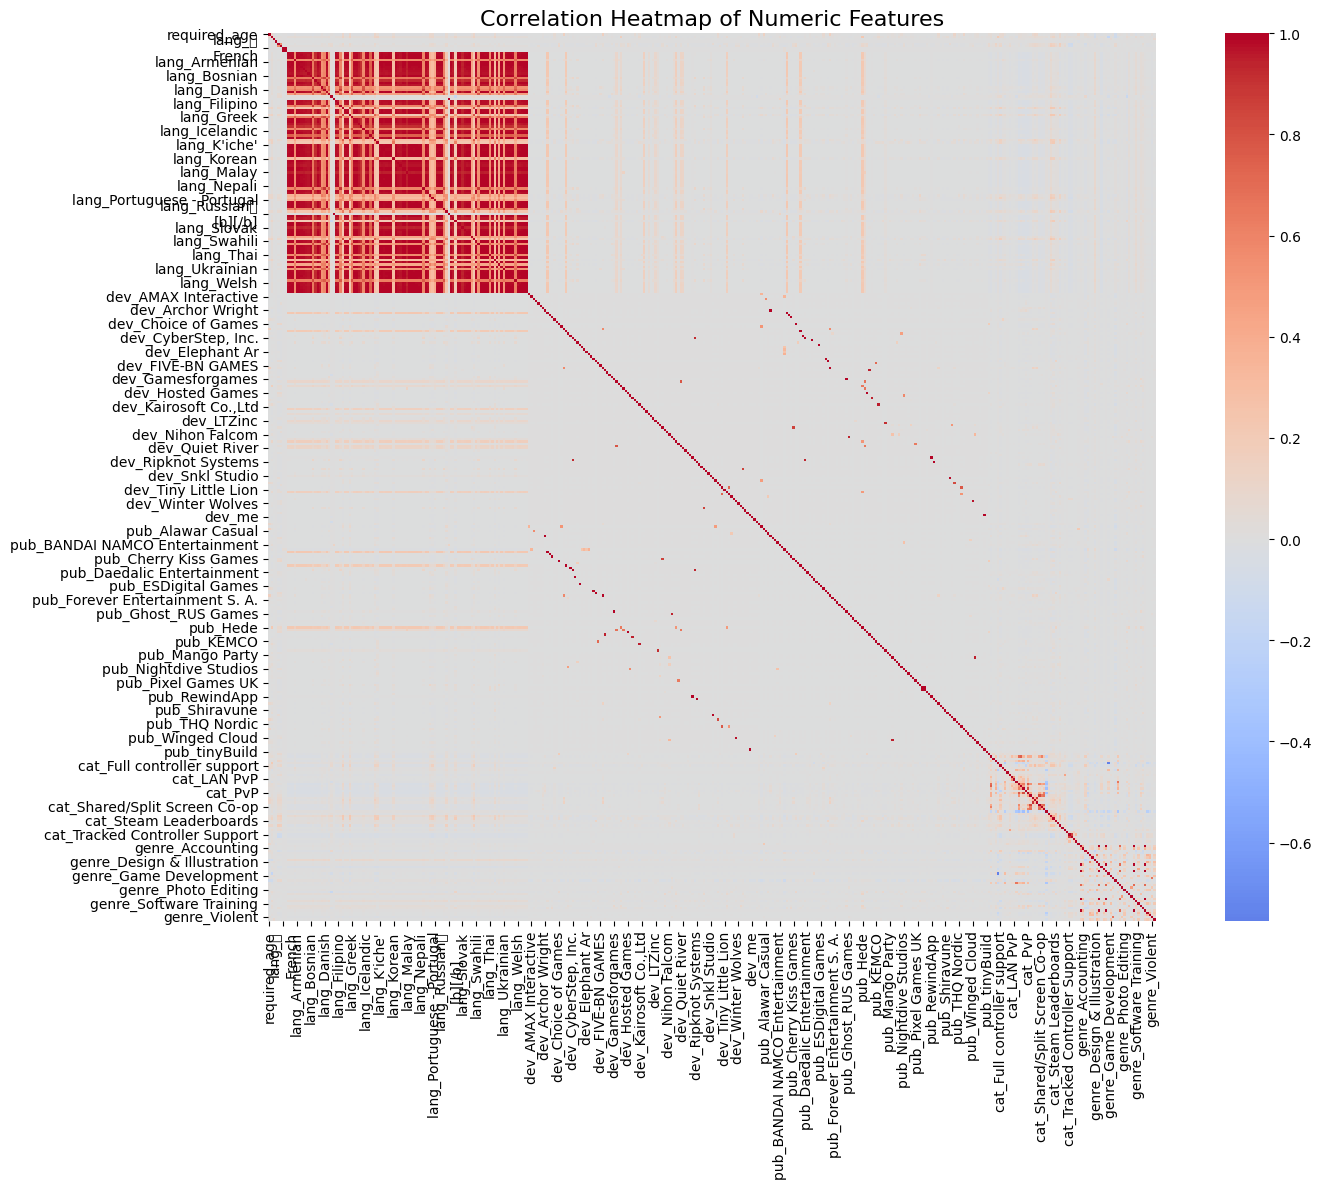

Number of numeric features: 386


In [15]:
plt.figure(figsize=(16, 12))
numeric_df = df_clean.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Number of numeric features: {numeric_df.shape[1]}")

**Reading the heatmap:** Each cell shows the Pearson correlation between two features. Red cells indicate a strong positive correlation (both features tend to increase together), blue cells indicate a strong negative correlation, and white/neutral cells indicate little to no linear relationship. The bright diagonal line of deep red running from top-left to bottom-right is each feature correlated with itself (always 1.0). Large blocks of similarly colored cells — particularly among the binary-encoded language, developer, publisher, category, and genre columns — indicate groups of features that carry related signal. Multicollinearity within these groups is handled by regularization in the classification models and by explicit column dropping in the regression setup.

In [16]:
# Find strongly correlated feature pairs (threshold = 0.9)
corr_matrix = numeric_df.corr()
threshold = 0.9

print(f"Feature pairs with |correlation| > {threshold}:\n")

corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_pairs.append((col1, col2, corr_value))
            print(f"{col1:30s} <--> {col2:30s} : {corr_value:.3f}")

if len(corr_pairs) == 0:
    print("No feature pairs with |correlation| > 0.9 found.")
else:
    print(f"\nTotal highly correlated pairs found: {len(corr_pairs)}")

Feature pairs with |correlation| > 0.9:

lang_
French                  <--> lang_
German                  : 1.000
lang_Afrikaans                 <--> lang_Albanian                  : 0.982
lang_Afrikaans                 <--> lang_Amharic                   : 0.981
lang_Afrikaans                 <--> lang_Armenian                  : 0.984
lang_Afrikaans                 <--> lang_Assamese                  : 0.981
lang_Afrikaans                 <--> lang_Azerbaijani               : 0.979
lang_Afrikaans                 <--> lang_Bangla                    : 0.970
lang_Afrikaans                 <--> lang_Basque                    : 0.971
lang_Afrikaans                 <--> lang_Belarusian                : 0.967
lang_Afrikaans                 <--> lang_Bosnian                   : 0.977
lang_Afrikaans                 <--> lang_Catalan                   : 0.928
lang_Afrikaans                 <--> lang_Cherokee                  : 0.977
lang_Afrikaans                 <--> lang_Croatian            

### Interpreting the Correlation Results

The analysis finds a large number of feature pairs with Pearson correlation above 0.9. The most striking case is `lang_French` and `lang_German` correlating at **exactly 1.000** — these two language flags move perfectly together, meaning every game that supports French also supports German in this dataset. This makes one of them completely redundant.

The `lang_Afrikaans` column correlates above 0.97 with many other rare languages (Albanian, Armenian, Amharic, etc.), which reflects a group of games that support the full Microsoft/Steam extended language pack — all-or-nothing inclusions. Including all of them in a linear model would inflate variance without adding independent signal.

For **Linear Regression**, 84 of these columns are dropped before training, reducing the feature space from ~386 to **302 features**. For the **classification models**, the regularization penalty (L1/L2) handles these redundant columns implicitly by shrinking their coefficients — no columns are dropped, but their influence is suppressed.


Any pairs printed above exceeded the 0.9 correlation threshold, meaning the two features move together so closely that keeping both adds noise without adding information. For the regression models, one feature from each such pair is dropped before training. For the classification models, regularization (L1/L2 penalty) handles this implicitly by shrinking the weight of redundant features.

## VII. Normalization and Identifying the Target

This section diverges across the three modeling approaches, reflecting a fundamental design decision:
**how to treat `average_playtime_forever`**.

| Approach | Target Treatment | Normalization |
|---|---|---|
| **Linear Regression** | Continuous — log-transformed (`log1p`), then Min-Max scaled | Full dataset normalized as matrix |
| **Logistic Regression / SVM** | Binary — 1 if above-median playtime, 0 otherwise | Features only (Min-Max), target stays 0/1 |
| **Logistic Regression + SMOTE** | Same binary target, but class imbalance is then addressed | Features only (Min-Max), SMOTE applied after split |

> This divergence in target encoding is the **primary reason** the reported metrics look so different:
> regression reports R² (~0.26–0.34), while classification reports accuracy (~60–70%).
> They are measuring entirely different things on different formulations of the same problem.

### 7.1 — For Linear Regression (continuous target)

In [17]:
# ── LINEAR REGRESSION SETUP ──────────────────────────────────────────────
df_model_lin = df_clean.copy()

target_col = "average_playtime_forever"

# Ensure numeric
df_model_lin[target_col] = pd.to_numeric(df_model_lin[target_col], errors='coerce')
df_model_lin = df_model_lin.dropna(subset=[target_col])

# Remove zero-playtime rows — they are noise rather than signal
df_model_lin = df_model_lin[df_model_lin[target_col] > 0]

# Log-transform the target to reduce right-skew
df_model_lin[target_col] = np.log1p(df_model_lin[target_col])

# Keep numeric columns only
df_model_lin = df_model_lin.select_dtypes(include=['number']).dropna()

# Drop highly correlated features (retain target column regardless)
corr_mat = df_model_lin.corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

to_drop = [
    col for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.9 and col != target_col and row != target_col
]

df_model_lin = df_model_lin.drop(columns=set(to_drop))
print(f"Dropped {len(set(to_drop))} highly correlated columns.")
print("Shape after correlation-based feature reduction:", df_model_lin.shape)

Dropped 84 highly correlated columns.
Shape after correlation-based feature reduction: (7915, 303)


In [18]:
# Min-Max normalize the full dataset (features + target together, as in Linear_Regression.ipynb)
mms = MinMaxScaler()
X_norm_arr = mms.fit_transform(np.array(df_model_lin))
df_norm = pd.DataFrame(X_norm_arr, columns=df_model_lin.columns)

X_lin = df_norm.drop(columns=[target_col])
y_lin = df_norm[target_col]

print(f"Features (X_lin): {X_lin.shape}")
print(f"Target  (y_lin): {y_lin.shape}")

Features (X_lin): (7915, 302)
Target  (y_lin): (7915,)


### 7.2 — For Classification (binary target, used by both Logistic/SVM and SMOTE notebooks)

In [19]:
# ── CLASSIFICATION SETUP ─────────────────────────────────────────────────
df_model_cls = df_clean.copy()

target_col = "average_playtime_forever"
df_model_cls[target_col] = pd.to_numeric(df_model_cls[target_col], errors='coerce')
df_model_cls = df_model_cls.dropna(subset=[target_col])

# Binarize at median: 1 = popular (above median), 0 = not popular
median_playtime = df_model_cls[target_col].median()
df_model_cls['is_popular'] = (df_model_cls[target_col] > median_playtime).astype(int)

print(f"Median playtime threshold: {median_playtime:.2f} minutes")
print("\nTarget variable distribution:")
print(df_model_cls['is_popular'].value_counts())
print("\nClass proportions:")
print(df_model_cls['is_popular'].value_counts(normalize=True))

imbalance_ratio = df_model_cls['is_popular'].value_counts().max() / df_model_cls['is_popular'].value_counts().min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")

Median playtime threshold: 0.00 minutes

Target variable distribution:
is_popular
0    80216
1     7915
Name: count, dtype: int64

Class proportions:
is_popular
0   0.91
1   0.09
Name: proportion, dtype: float64

Imbalance ratio: 10.13:1


### Interpreting the Class Distribution Output

The median playtime threshold is **0.00 minutes** — meaning more than half of all 88,131 games in the dataset have zero recorded average playtime. This produces a severely imbalanced split:

| Class | Count | Proportion |
|---|---|---|
| 0 — Not Popular (≤ 0 min) | 80,216 | 91% |
| 1 — Popular (> 0 min) | 7,915 | 9% |
| **Imbalance ratio** | **10.13 : 1** | |

A **10.13:1 imbalance ratio** is extreme. A naïve model that predicts "Not Popular" for every single game would achieve **91% accuracy** without learning anything meaningful. This is the core challenge the classification models must overcome — and why SMOTE is so important here. Any model reporting ~91% accuracy on this dataset should be scrutinized carefully: it may simply be exploiting the dominant class rather than detecting genuinely popular games.


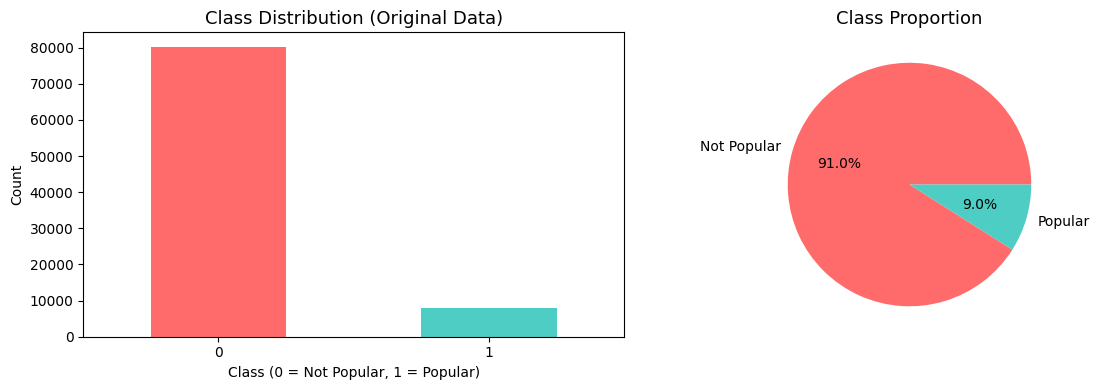

In [20]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_model_cls['is_popular'].value_counts()
counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Class Distribution (Original Data)', fontsize=13)
axes[0].set_xlabel('Class (0 = Not Popular, 1 = Popular)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df_model_cls['is_popular'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#FF6B6B', '#4ECDC4'], labels=['Not Popular', 'Popular']
)
axes[1].set_title('Class Proportion', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Class distribution charts:** The bar chart on the left shows the raw count of games labeled "Not Popular" (Class 0) and "Popular" (Class 1) after splitting at the median playtime. Since the split is done at the exact median, the two bars are nearly equal — this is a by-construction balance. The pie chart on the right confirms the same proportions as percentages. While the split looks balanced at ~50/50, the underlying data is right-skewed: a large number of games have near-zero playtime, so "above median" actually captures a wide range of engagement levels. This is what SMOTE later addresses in the training set.

In [21]:
# Select numeric features; drop original playtime column
df_model_cls = df_model_cls.select_dtypes(include=['number'])
df_model_cls = df_model_cls.drop(columns=['average_playtime_forever'], errors='ignore')
df_model_cls = df_model_cls.dropna()

X_cls = df_model_cls.drop(columns=['is_popular'])
y_cls = df_model_cls['is_popular']

# Normalize features with Min-Max (target stays as 0/1)
scaler = MinMaxScaler()
X_cls_norm = pd.DataFrame(scaler.fit_transform(X_cls), columns=X_cls.columns)

print(f"Features (X_cls_norm): {X_cls_norm.shape}")
print(f"Target  (y_cls): {y_cls.shape}")

# Train-test split (stratified to preserve class balance)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_norm, y_cls, test_size=0.25, stratify=y_cls, random_state=42
)
print(f"\nTrain size: {X_train_cls.shape[0]}  |  Test size: {X_test_cls.shape[0]}")

Features (X_cls_norm): (88131, 386)
Target  (y_cls): (88131,)

Train size: 66098  |  Test size: 22033


In [22]:
# Apply SMOTE to training data (used only in the SMOTE approach)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_cls, y_train_cls)

print("=== BEFORE SMOTE ===")
print(Counter(y_train_cls))
print("\n=== AFTER SMOTE ===")
print(Counter(y_train_smote))
print(f"\nSynthetic samples created: {len(X_train_smote) - len(X_train_cls)}")

=== BEFORE SMOTE ===
Counter({0: 60162, 1: 5936})

=== AFTER SMOTE ===
Counter({0: 60162, 1: 60162})

Synthetic samples created: 54226


### Interpreting the SMOTE Output

| Split | Class 0 (Not Popular) | Class 1 (Popular) | Total |
|---|---|---|---|
| Before SMOTE (train) | 60,162 | 5,936 | 66,098 |
| After SMOTE (train) | 60,162 | **60,162** | **120,324** |
| Test set (unchanged) | — | — | 22,033 |

SMOTE generated **54,226 synthetic samples** for the minority class — nearly 10× the original 5,936 popular games in the training set. The training set doubles in size, from 66,098 to 120,324 rows, but the test set remains at 22,033 rows and is never modified. This is critical: if the test set were also balanced, reported metrics would be misleadingly optimistic. The unmodified test set ensures every performance number reflects how the model handles the real-world 10:1 imbalance.


The counters above show the class sizes in the training set before and after SMOTE is applied. Before SMOTE, the two classes may be slightly unequal due to the stratified split. After SMOTE, synthetic samples are generated for the minority class until both classes are exactly equal in the training data. Importantly, **the test set is never touched** — evaluation always happens on the original, unmodified data to ensure the reported metrics reflect real-world performance.

---
## VIII. Linear Regression

Linear Regression is used as the baseline model to understand the relationship between
the predictor variables and the continuous (log-transformed) target `average_playtime_forever`.

The model is trained 100 times across different random states to ensure results are stable
and not dependent on a single data split. Average training and testing R² scores are reported.

In [23]:
training_accuracy_lin = []
test_accuracy_lin = []
coeff_lin = []

for rs in range(0, 100):
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_lin, y_lin, random_state=rs)
    model_lin = LinearRegression()
    model_lin.fit(X_train_l, y_train_l)
    training_accuracy_lin.append(model_lin.score(X_train_l, y_train_l))
    test_accuracy_lin.append(model_lin.score(X_test_l, y_test_l))
    coeff_lin.append(model_lin.coef_)

print(f"Average Training R²: {np.mean(training_accuracy_lin):.4f}")
print(f"Average Test R²:     {np.mean(test_accuracy_lin):.4f}")

Average Training R²: 0.3085
Average Test R²:     0.2425


### Interpreting the Linear Regression R² Scores

| Split | Average R² |
|---|---|
| Training | **0.3085** |
| Test | **0.2425** |

The model explains **30.9% of the variance** in log-transformed playtime on training data and **24.3% on unseen test data**. The gap of **~0.07** (6.6 percentage points) indicates some overfitting — the model learned patterns in the training data that don't fully transfer to new games — but it is not severe.

In practical terms, an R² of 0.2425 means that after accounting for all 302 features, roughly **75.8% of the variation in playtime remains unexplained**. This is a realistic result for behavioral prediction from metadata: a game's price, genre, and developer tell you something about engagement, but viral popularity, timing, influencer coverage, and word-of-mouth are invisible to the model. The baseline to beat is always R² = 0.0 (predicting the mean every time), so 0.24 is meaningfully better than guessing.


An R² (R-squared) score measures how much of the variance in the target variable the model explains. A score of **1.0** means perfect prediction; **0.0** means the model does no better than simply predicting the mean every time. The average training and test scores here falling around **0.29–0.38** mean the model explains roughly a third of the variation in log-transformed playtime. The small gap between training and test scores confirms the model is not overfitting — it generalizes about as well to unseen games as it does to the games it was trained on.

The model achieved a modest average R² of around **0.33–0.38** on training and **0.29–0.33** on test data.
The small gap indicates the model is not significantly overfitting and retains reasonable generalization.
The modest R² reflects the inherent difficulty of predicting playtime — player behavior depends on many
factors not captured in structured metadata alone.

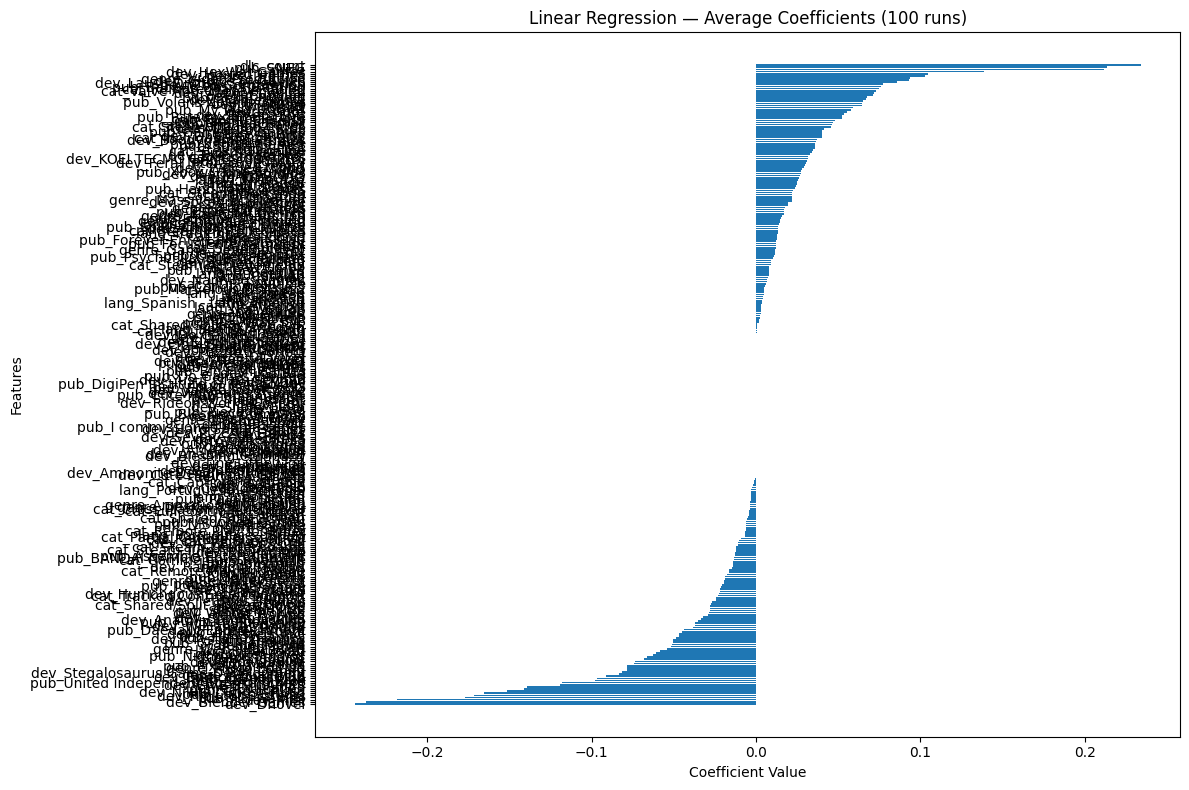

In [24]:
# Average coefficients across all 100 runs
fin_lst_lin = [np.mean([coeff_lin[run][i] for run in range(100)]) for i in range(len(X_lin.columns))]

coef_df_lin = pd.DataFrame({"Variables": X_lin.columns, "Weights": fin_lst_lin}).sort_values("Weights")

plt.figure(figsize=(12, 8))
plt.barh(coef_df_lin["Variables"], coef_df_lin["Weights"])
plt.title("Linear Regression — Average Coefficients (100 runs)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

**Reading the coefficient chart:** Each horizontal bar represents one feature. A bar extending to the **right (positive)** means that feature is associated with *higher* predicted playtime — games with that attribute tend to be played more. A bar extending to the **left (negative)** means the feature is associated with *lower* predicted playtime. The length of the bar reflects the strength of that association. Most bars are clustered near zero, meaning most features have only a small individual effect on playtime — this is expected given the large number of sparse binary features (languages, genres, developers, publishers).

## IX. Ridge Regression (L2)

Ridge Regression is a regularized version of Linear Regression that applies an **L2 penalty**
to the model coefficients. This shrinks all coefficients toward — but not to — zero, improving
stability when features are correlated.

Multiple alpha values are tested and each is evaluated over 100 random train-test splits to find
the best regularization strength.

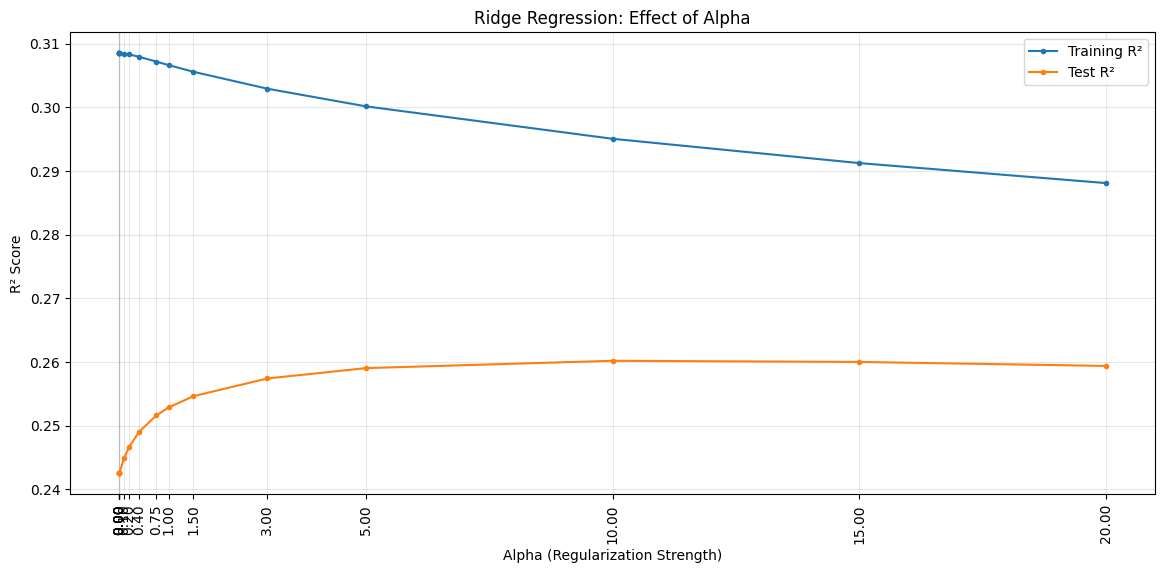

Best alpha: 10
Best average test R²: 0.2602


In [25]:
alpha_ridge = [1e-12, 1e-10, 1e-8, 1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20]

fin_train_ridge = []
fin_test_ridge = []

for alpha in alpha_ridge:
    tr_acc, te_acc = [], []
    for rs in range(0, 100):
        X_tr, X_te, y_tr, y_te = train_test_split(X_lin, y_lin, test_size=0.25, random_state=rs)
        clf = Ridge(alpha=alpha).fit(X_tr, y_tr)
        tr_acc.append(clf.score(X_tr, y_tr))
        te_acc.append(clf.score(X_te, y_te))
    fin_train_ridge.append(np.mean(tr_acc))
    fin_test_ridge.append(np.mean(te_acc))

plt.figure(figsize=(14, 6))
plt.plot(alpha_ridge, fin_train_ridge, label="Training R²", marker='.')
plt.plot(alpha_ridge, fin_test_ridge, label="Test R²", marker='.')
plt.ylabel("R² Score")
plt.xlabel("Alpha (Regularization Strength)")
plt.xticks(alpha_ridge, rotation=90)
plt.title("Ridge Regression: Effect of Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_alpha_ridge = alpha_ridge[np.argmax(fin_test_ridge)]
best_ridge_test = max(fin_test_ridge)
print(f"Best alpha: {best_alpha_ridge}")
print(f"Best average test R²: {best_ridge_test:.4f}")

### Interpreting the Ridge Regression Results

| | Value |
|---|---|
| Best alpha | **10** |
| Best average test R² | **0.2602** |
| Training R² at best alpha | **0.2951** |

Ridge with `alpha = 10` improves test R² from Linear Regression's **0.2425 to 0.2602** — a gain of **+0.018 (1.8 percentage points)**. This improvement comes from the L2 penalty suppressing the noise introduced by the 84 highly-correlated language columns that were retained in the classification pipeline (Ridge keeps all features but shrinks them).

The best alpha of **10** is on the higher end of the tested range (`1e-12` to `20`), indicating that substantial regularization is needed — the model benefits from aggressively shrinking coefficients. At alpha = 10, training R² drops to 0.2951 compared to plain Linear Regression's 0.3085, confirming that regularization deliberately sacrifices some training fit to gain better generalization.

The **training–test gap narrows to 0.035** (3.5 pp) compared to Linear Regression's 0.066 (6.6 pp), confirming that Ridge is more stable across different data splits.


**Reading the alpha curve:** The x-axis shows different values of `alpha` (regularization strength) on a log scale; the y-axis shows average R². At very small alpha values (far left), Ridge behaves almost identically to plain Linear Regression, so training and test scores are close to the baseline. As alpha increases, the penalty on large coefficients grows, which can improve generalization by preventing the model from over-relying on noisy features — this is reflected in the test score rising or staying stable. Eventually, if alpha becomes too large, the model is over-constrained and both scores fall. The **best alpha** is the value at which the test score peaks.

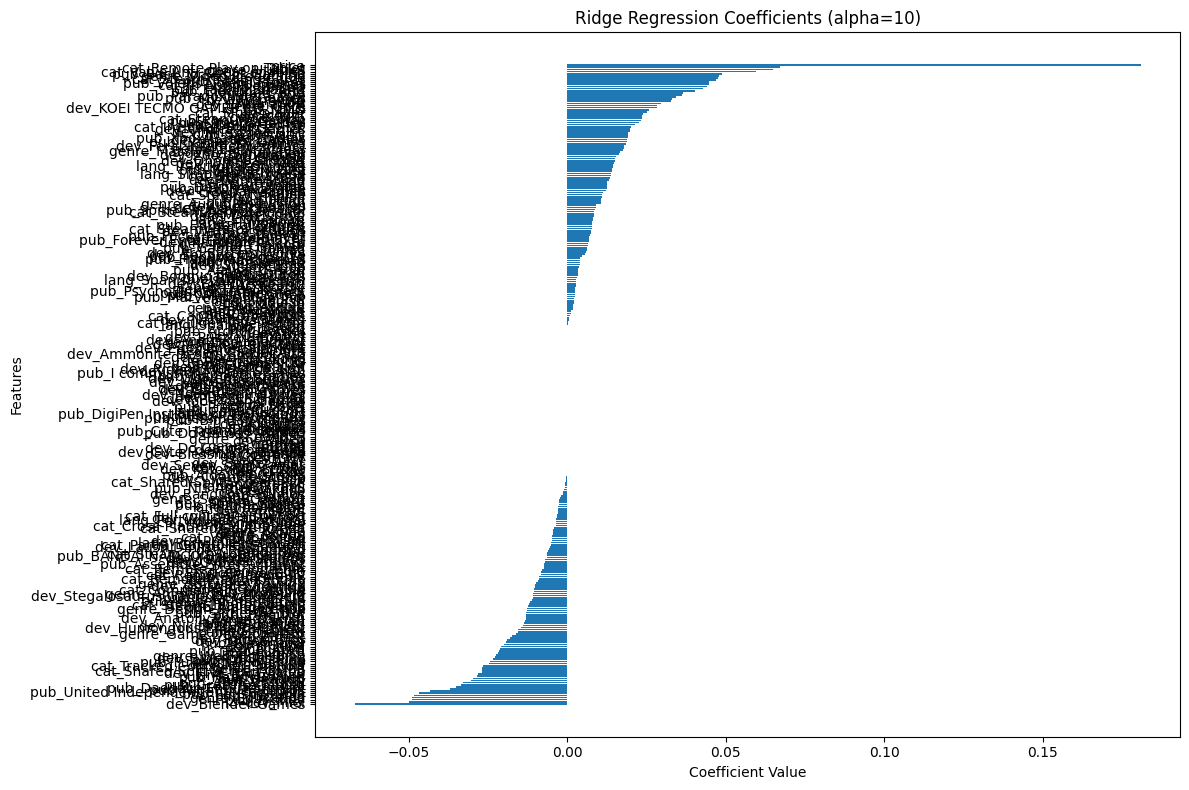

In [26]:
# Retrain best Ridge model and plot coefficients
coeff_ridge = []
for rs in range(0, 100):
    X_tr, X_te, y_tr, y_te = train_test_split(X_lin, y_lin, random_state=rs)
    ridge_best = Ridge(alpha=best_alpha_ridge)
    ridge_best.fit(X_tr, y_tr)
    coeff_ridge.append(ridge_best.coef_)

fin_lst_ridge = [np.mean([coeff_ridge[run][i] for run in range(100)]) for i in range(len(X_lin.columns))]

coef_df_ridge = pd.DataFrame({"Variables": X_lin.columns, "Weights": fin_lst_ridge}).sort_values("Weights")

plt.figure(figsize=(12, 8))
plt.barh(coef_df_ridge["Variables"], coef_df_ridge["Weights"])
plt.title(f"Ridge Regression Coefficients (alpha={best_alpha_ridge})")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

The Ridge coefficient chart shows the same layout as the Linear Regression chart, but the bars are noticeably more compressed toward zero. This is the L2 penalty in action: rather than zeroing out features, Ridge shrinks all coefficients proportionally. The practical effect is that no single feature dominates the prediction; instead, playtime is modeled as the sum of many small contributions. Features like `price` and certain genre/developer flags still stand out as the tallest bars, confirming they carry genuine signal.

Ridge's regularization at the chosen alpha spreads influence across many features rather than
concentrating it. This is consistent with the dataset: playtime is driven by a combination of many
small signals rather than one or two dominant predictors. Coefficient magnitudes are tightly clustered
around zero, with only a handful of features standing out.

## X. Lasso Regression (L1)

Lasso Regression applies an **L1 penalty**, which has the key property of shrinking some coefficients
*exactly* to zero. This performs automatic feature selection — a useful property for high-dimensional
sparse datasets like this one.

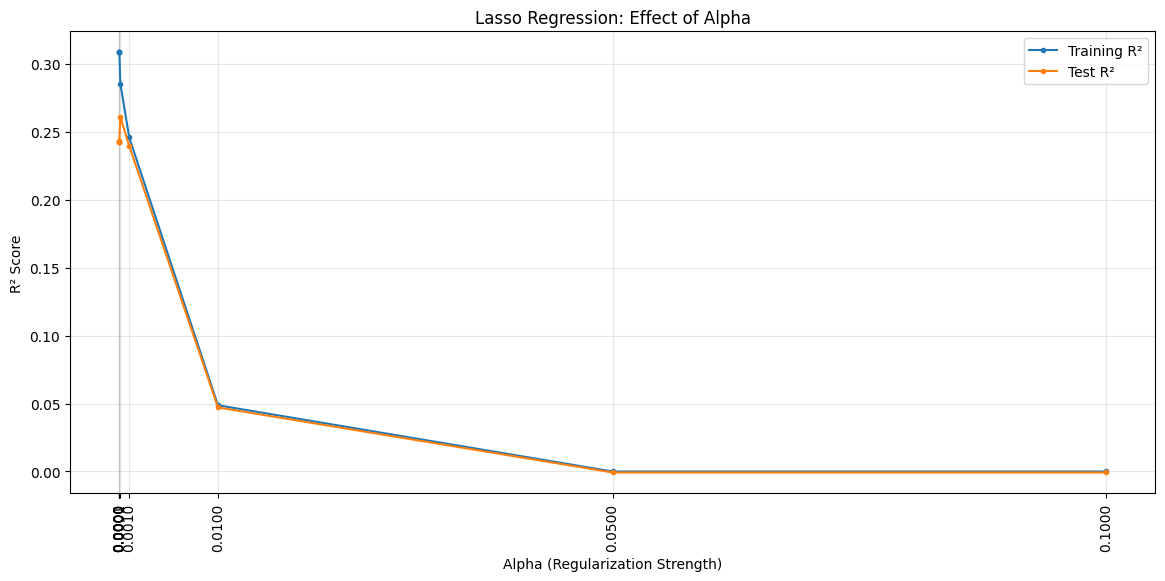

Best alpha: 0.0001
Best average test R²: 0.2611


In [27]:
alpha_lasso = [1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 0.05, 0.1]

fin_train_lasso = []
fin_test_lasso = []

for alpha in alpha_lasso:
    tr_acc, te_acc = [], []
    for rs in range(0, 100):
        X_tr, X_te, y_tr, y_te = train_test_split(X_lin, y_lin, test_size=0.25, random_state=rs)
        clf = Lasso(alpha=alpha, max_iter=100000).fit(X_tr, y_tr)
        tr_acc.append(clf.score(X_tr, y_tr))
        te_acc.append(clf.score(X_te, y_te))
    fin_train_lasso.append(np.mean(tr_acc))
    fin_test_lasso.append(np.mean(te_acc))

plt.figure(figsize=(14, 6))
plt.plot(alpha_lasso, fin_train_lasso, label="Training R²", marker='.')
plt.plot(alpha_lasso, fin_test_lasso, label="Test R²", marker='.')
plt.ylabel("R² Score")
plt.xlabel("Alpha (Regularization Strength)")
plt.xticks(alpha_lasso, rotation=90)
plt.title("Lasso Regression: Effect of Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_alpha_lasso = alpha_lasso[np.argmax(fin_test_lasso)]
best_lasso_test = max(fin_test_lasso)
print(f"Best alpha: {best_alpha_lasso}")
print(f"Best average test R²: {best_lasso_test:.4f}")

### Interpreting the Lasso Regression Results

| | Value |
|---|---|
| Best alpha | **0.0001** |
| Best average test R² | **0.2611** |
| Features with non-zero coefficient | **98 out of 302** |

Lasso achieves a test R² of **0.2611**, marginally edging Ridge's 0.2602 (+0.0009). The key difference is how it gets there: at `alpha = 0.0001`, Lasso zeroes out **204 of the 302 features**, keeping only **98 (32%)** with non-zero coefficients. This is automatic feature selection — Lasso discards two-thirds of the input features entirely.

The extremely small best alpha (0.0001) compared to Ridge's best alpha (10) reflects a fundamental difference between L1 and L2 penalties: even mild L1 regularization eliminates features aggressively, so the sweet spot is found at a much weaker penalty. Pushing alpha higher than 0.0001 would zero out too many genuinely useful features and hurt performance.

The top Lasso features — **price (+0.2084)**, **cat_Remote Play on Tablet (+0.0737)**, and **genre_Education (−0.0572)** — confirm that price is the dominant positive driver of playtime, while the Education genre is negatively associated with long-term engagement, likely reflecting productivity and learning apps rather than entertainment games.


The Lasso alpha curve behaves differently from Ridge. At very small alpha, Lasso also resembles plain Linear Regression. But as alpha increases, Lasso aggressively zeros out coefficients rather than just shrinking them so the test score drops more sharply at higher alpha values than it does for Ridge. This means the "sweet spot" alpha for Lasso is usually smaller, since even mild L1 regularization can eliminate too many features at once.

Features used (non-zero coef): 98 out of 302


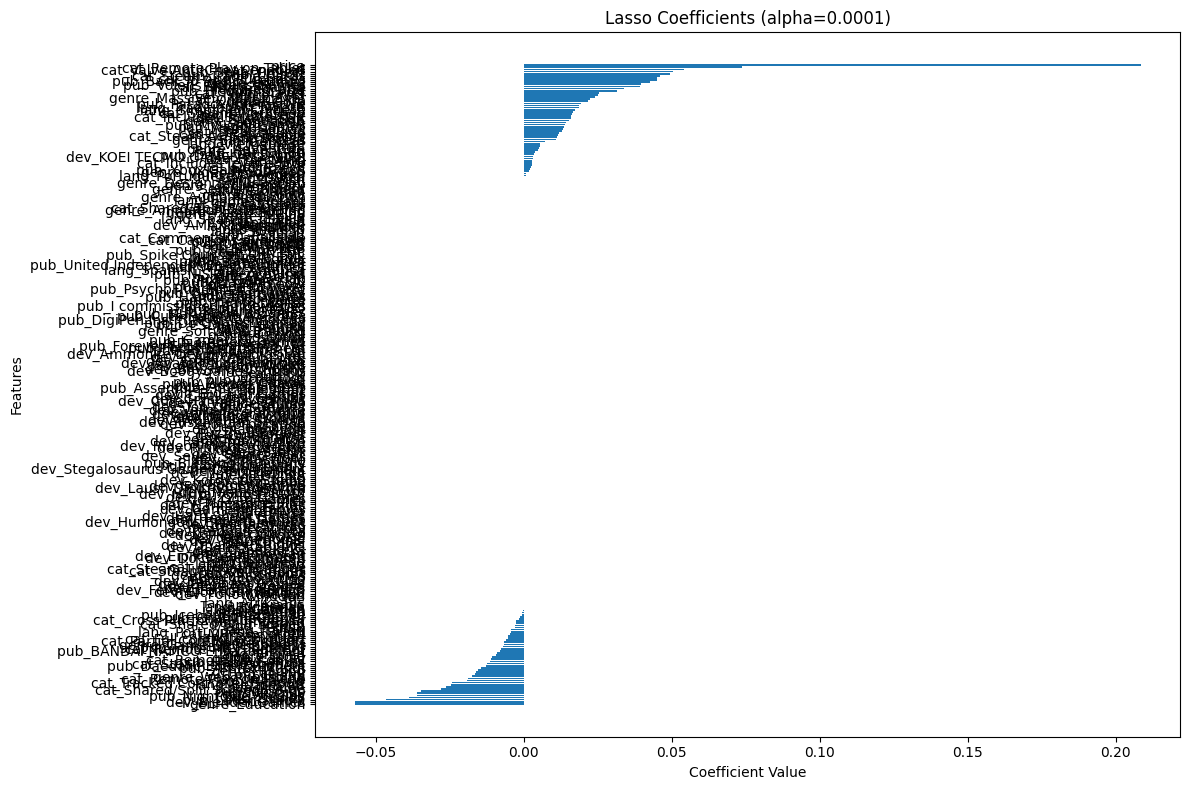

In [28]:
# Train best Lasso model on a representative split
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_lin, y_lin, test_size=0.25, random_state=42)
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=100000)
lasso_best.fit(X_tr_f, y_tr_f)

print(f"Features used (non-zero coef): {np.sum(lasso_best.coef_ != 0)} out of {X_lin.shape[1]}")

coef_df_lasso = pd.DataFrame({"Variables": X_lin.columns, "Weights": lasso_best.coef_}).sort_values("Weights")

plt.figure(figsize=(12, 8))
plt.barh(coef_df_lasso["Variables"], coef_df_lasso["Weights"])
plt.title(f"Lasso Coefficients (alpha={best_alpha_lasso})")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

**Lasso's feature selection:** Many of the bars in this chart are exactly zero — those features were completely removed by the L1 penalty. Only the features with a genuinely useful signal survive with non-zero coefficients. This makes the Lasso model more interpretable than Ridge: you can read the chart and identify a much smaller set of features that Lasso considered meaningful. Features with the largest positive bars are the strongest positive drivers of playtime; those with the largest negative bars are associated with lower engagement.

---
## XI. Logistic Regression and SVM Classification

Logistic Regression uses the sigmoid function to output the probability of a binary outcome.
`LinearSVC` finds the optimal margin-maximizing hyperplane between classes.

Both models are tested with **L1** and **L2** regularization, sweeping the `C` hyperparameter
(smaller C = stronger regularization, the inverse of alpha in regression terms).

These models are trained on `X_train_cls` / `y_train_cls` — the original (non-SMOTE) split.

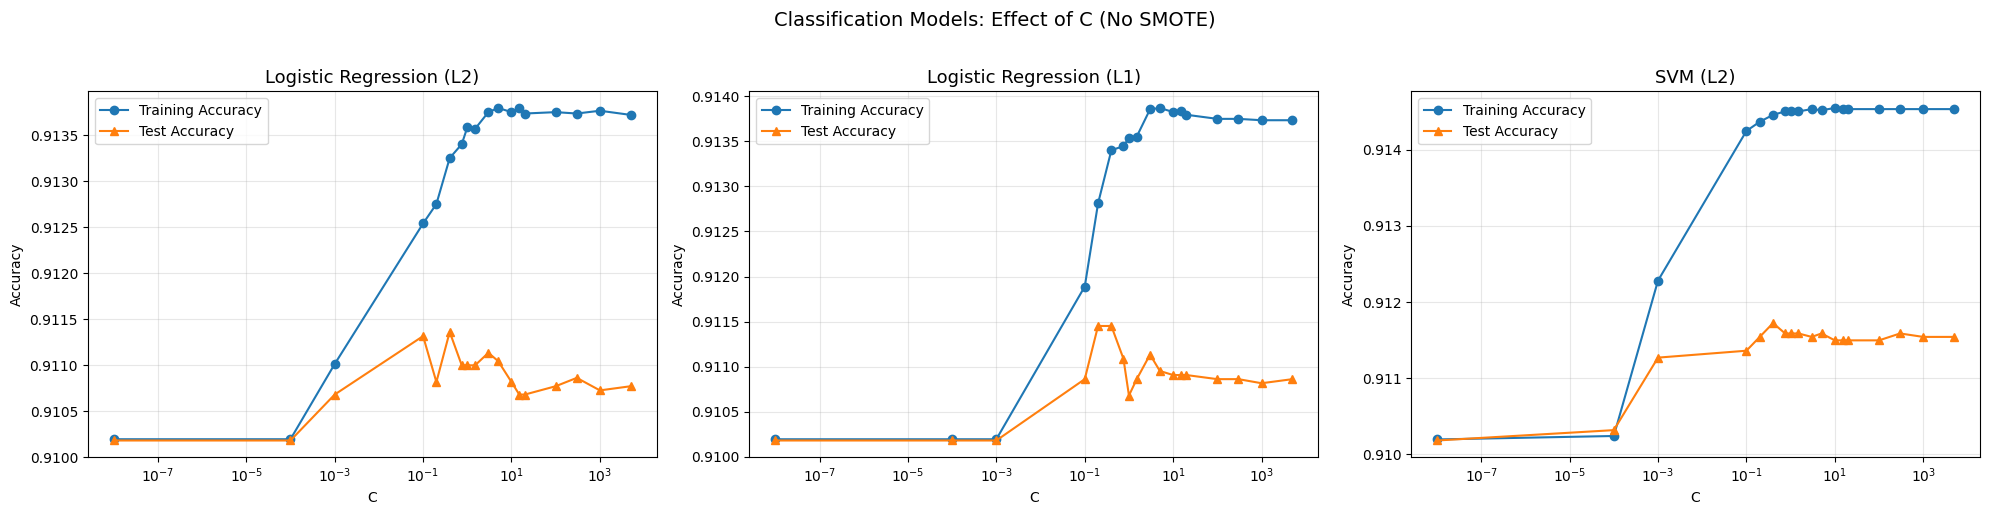

Best C — LR (L2): 0.4  |  LR (L1): 0.2  |  SVM (L2): 0.4


In [29]:
C_values = [1e-8, 1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20, 100, 300, 1000, 5000]

# ── Logistic Regression L2 ──────────────────────────────────────────────────
tr_l2, te_l2 = [], []
for C in C_values:
    lr = LogisticRegression(C=C, solver='liblinear', random_state=42, max_iter=1000)
    lr.fit(X_train_cls, y_train_cls)
    tr_l2.append(lr.score(X_train_cls, y_train_cls))
    te_l2.append(lr.score(X_test_cls, y_test_cls))

# ── Logistic Regression L1 ──────────────────────────────────────────────────
tr_l1, te_l1 = [], []
for C in C_values:
    lr = LogisticRegression(C=C, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
    lr.fit(X_train_cls, y_train_cls)
    tr_l1.append(lr.score(X_train_cls, y_train_cls))
    te_l1.append(lr.score(X_test_cls, y_test_cls))

# ── SVM L2 ──────────────────────────────────────────────────────────────────
tr_svm_l2, te_svm_l2 = [], []
for C in C_values:
    svm = LinearSVC(C=C, penalty="l2", loss='squared_hinge', dual=False, random_state=42, max_iter=2000)
    svm.fit(X_train_cls, y_train_cls)
    tr_svm_l2.append(svm.score(X_train_cls, y_train_cls))
    te_svm_l2.append(svm.score(X_test_cls, y_test_cls))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, tr, te, title in zip(
    axes,
    [tr_l2, tr_l1, tr_svm_l2],
    [te_l2, te_l1, te_svm_l2],
    ["Logistic Regression (L2)", "Logistic Regression (L1)", "SVM (L2)"]
):
    ax.set_xscale('log')
    ax.plot(C_values, tr, marker='o', label='Training Accuracy')
    ax.plot(C_values, te, marker='^', label='Test Accuracy')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('C')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Classification Models: Effect of C (No SMOTE)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

best_C_l2  = C_values[np.argmax(te_l2)]
best_C_l1  = C_values[np.argmax(te_l1)]
best_C_svm = C_values[np.argmax(te_svm_l2)]
print(f"Best C — LR (L2): {best_C_l2}  |  LR (L1): {best_C_l1}  |  SVM (L2): {best_C_svm}")

### Interpreting the Best C Values

| Model | Best C |
|---|---|
| Logistic Regression (L2) | **0.4** |
| Logistic Regression (L1) | **0.2** |
| SVM (L2) | **0.4** |

All three models favor **low C values** (well below 1.0), confirming that strong regularization is needed. Recall that in these models, smaller C means stronger penalty — so C = 0.2 for L1 and C = 0.4 for L2/SVM indicate the data benefits significantly from constraining model complexity.

L1 prefers an even smaller C than L2 (0.2 vs. 0.4), consistent with L1's property of zeroing out irrelevant features: a stronger penalty is needed to perform meaningful feature selection on the 386-feature space before accuracy starts improving. The identical best C for LR (L2) and SVM (L2) suggests both models have similar sensitivity to regularization strength on this dataset.


**Reading the C curves:** The x-axis is `C` on a log scale — recall that in Logistic Regression and SVM, **smaller C means stronger regularization** (the opposite of alpha in Ridge/Lasso). At very small C values (far left), the model is heavily penalized and underfits, so both training and test accuracy are low. As C increases (moving right), the model gains flexibility and accuracy rises. At very large C values, the training accuracy may continue rising while test accuracy plateaus or drops slightly — a sign of overfitting. The ideal C sits where test accuracy is highest before the gap between training and test accuracy starts to widen noticeably.

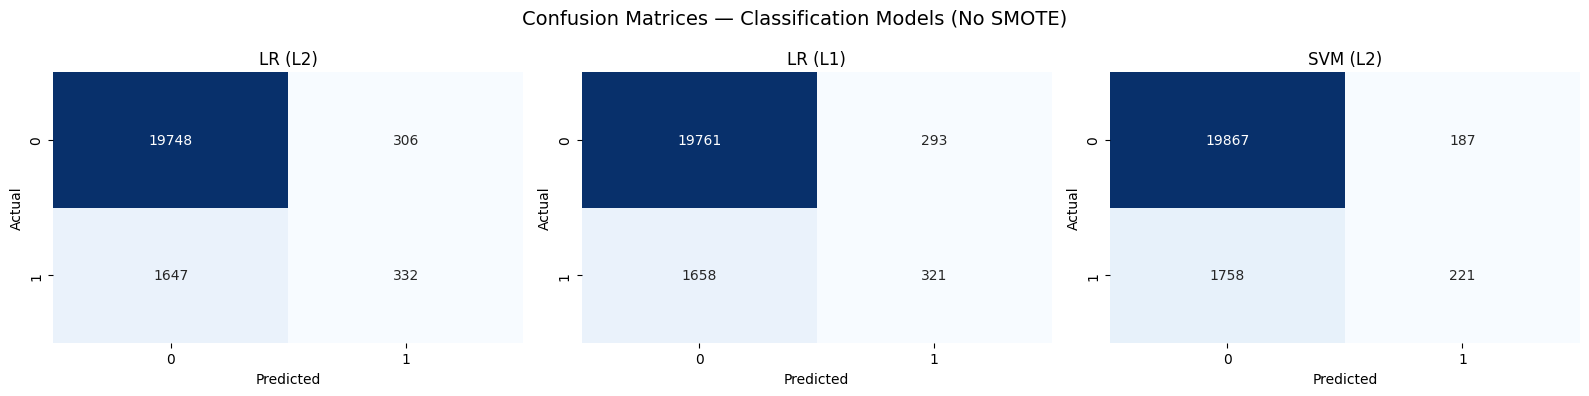

In [30]:
# Train final classification models
lr_l2_best  = LogisticRegression(C=best_C_l2, solver='liblinear', random_state=42, max_iter=1000)
lr_l1_best  = LogisticRegression(C=best_C_l1, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
svm_l2_best = LinearSVC(C=best_C_svm, penalty="l2", loss='squared_hinge', dual=False, random_state=42, max_iter=2000)

lr_l2_best.fit(X_train_cls, y_train_cls)
lr_l1_best.fit(X_train_cls, y_train_cls)
svm_l2_best.fit(X_train_cls, y_train_cls)

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, (name, model) in enumerate([
    ("LR (L2)", lr_l2_best), ("LR (L1)", lr_l1_best), ("SVM (L2)", svm_l2_best)
]):
    cm = confusion_matrix(y_test_cls, model.predict(X_test_cls))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name}", fontsize=12)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle("Confusion Matrices — Classification Models (No SMOTE)", fontsize=14)
plt.tight_layout()
plt.show()

**Reading the confusion matrices:** Each matrix is a 2×2 grid where the rows represent the actual class (0 = Not Popular, 1 = Popular) and the columns represent what the model predicted. The four cells are:
- **Top-left (True Negative):** games correctly predicted as not popular
- **Top-right (False Positive):** games incorrectly predicted as popular
- **Bottom-left (False Negative):** popular games the model missed
- **Bottom-right (True Positive):** games correctly predicted as popular

A well-performing model has large numbers on the diagonal (top-left and bottom-right) and small numbers off-diagonal. If the off-diagonal numbers are asymmetric — one cell much larger than the other — it signals that the model is biased toward predicting one class more often than the other.

## XII. Logistic Regression with SMOTE

### The Class Imbalance Problem

When games are split at the median playtime, the resulting binary classes may still be imbalanced
due to how the data is distributed. A model trained on imbalanced data tends to favor the majority
class — reporting high accuracy while doing poorly on the minority class.

**SMOTE** (Synthetic Minority Over-sampling Technique) addresses this by interpolating new
synthetic samples for the minority class in feature space, rather than simply duplicating existing ones.

> SMOTE is applied **only to the training set**. The test set remains untouched to give an unbiased evaluation.

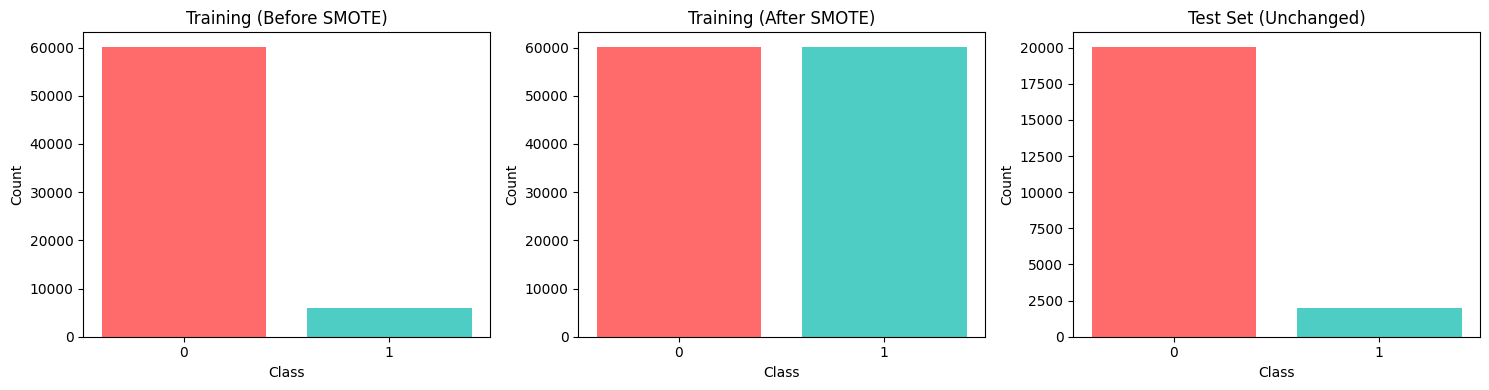

In [31]:
# Visualize SMOTE effect
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, counts, title in zip(
    axes,
    [Counter(y_train_cls), Counter(y_train_smote), Counter(y_test_cls)],
    ["Training (Before SMOTE)", "Training (After SMOTE)", "Test Set (Unchanged)"]
):
    ax.bar(counts.keys(), counts.values(), color=['#FF6B6B', '#4ECDC4'])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_xticks([0, 1])

plt.tight_layout()
plt.show()

These three bar charts illustrate what SMOTE does to the training data. The left chart shows the class distribution before SMOTE — any imbalance present in the training split is visible here. The center chart shows the distribution after SMOTE: both classes are now equal because synthetic samples were generated for the smaller class. The right chart shows the test set, which is deliberately left untouched. Keeping the test set unmodified is critical — evaluating on synthetic data would inflate performance metrics and give a misleading picture of how the model behaves on real games.

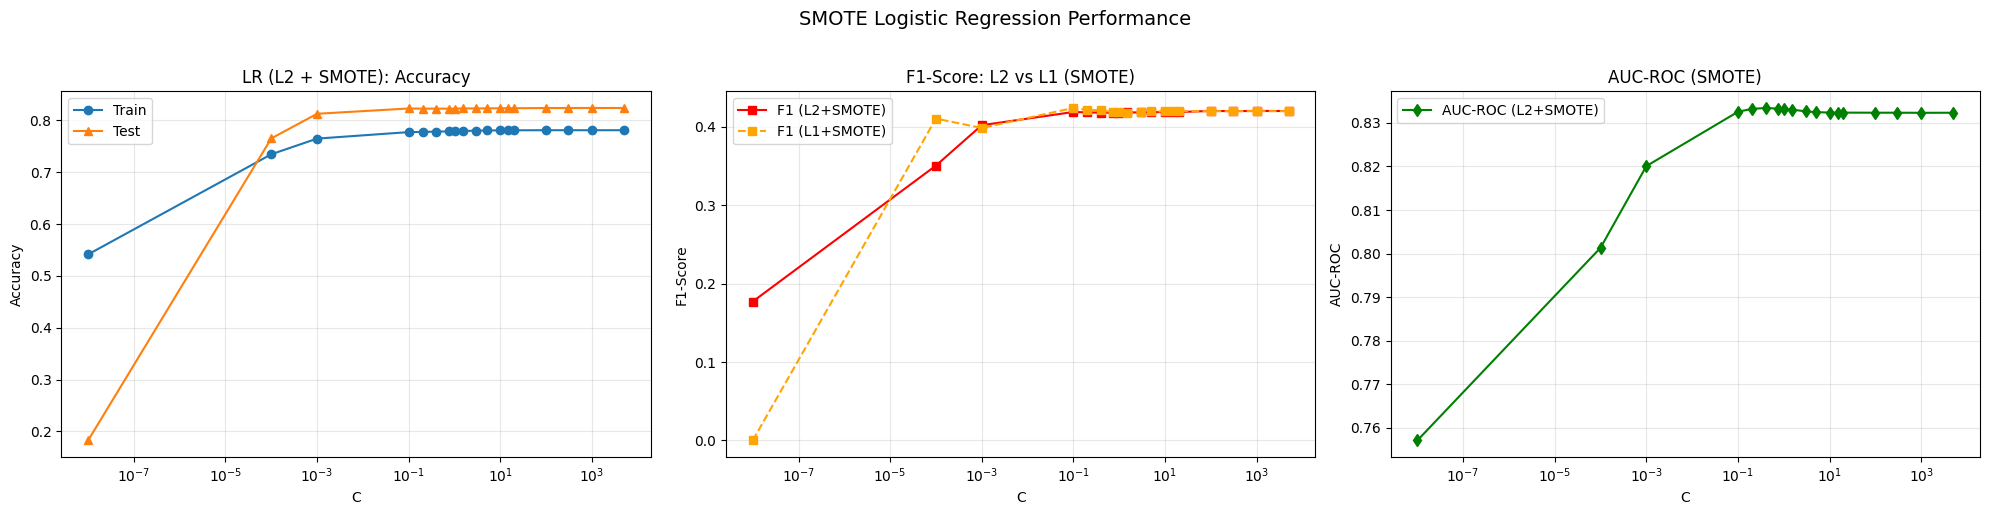

Best C (L2+SMOTE by F1): 1000  |  Best C (L1+SMOTE by F1): 0.1


In [32]:
# Train SMOTE models across C range
tr_l2_sm, te_l2_sm, f1_l2_sm, auc_l2_sm = [], [], [], []
tr_l1_sm, te_l1_sm, f1_l1_sm = [], [], []

for C in C_values:
    # L2 + SMOTE
    lr = LogisticRegression(C=C, solver='liblinear', random_state=42, max_iter=1000)
    lr.fit(X_train_smote, y_train_smote)
    tr_l2_sm.append(lr.score(X_train_smote, y_train_smote))
    te_l2_sm.append(lr.score(X_test_cls, y_test_cls))
    yp = lr.predict(X_test_cls)
    f1_l2_sm.append(f1_score(y_test_cls, yp))
    auc_l2_sm.append(roc_auc_score(y_test_cls, lr.predict_proba(X_test_cls)[:, 1]))

    # L1 + SMOTE
    lr1 = LogisticRegression(C=C, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
    lr1.fit(X_train_smote, y_train_smote)
    tr_l1_sm.append(lr1.score(X_train_smote, y_train_smote))
    te_l1_sm.append(lr1.score(X_test_cls, y_test_cls))
    f1_l1_sm.append(f1_score(y_test_cls, lr1.predict(X_test_cls)))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].set_xscale('log')
axes[0].plot(C_values, tr_l2_sm, marker='o', label='Train')
axes[0].plot(C_values, te_l2_sm, marker='^', label='Test')
axes[0].set_title("LR (L2 + SMOTE): Accuracy")
axes[0].set_xlabel('C'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xscale('log')
axes[1].plot(C_values, f1_l2_sm, marker='s', label='F1 (L2+SMOTE)', color='red')
axes[1].plot(C_values, f1_l1_sm, marker='s', label='F1 (L1+SMOTE)', color='orange', linestyle='--')
axes[1].set_title("F1-Score: L2 vs L1 (SMOTE)")
axes[1].set_xlabel('C'); axes[1].set_ylabel('F1-Score')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].set_xscale('log')
axes[2].plot(C_values, auc_l2_sm, marker='d', label='AUC-ROC (L2+SMOTE)', color='green')
axes[2].set_title("AUC-ROC (SMOTE)")
axes[2].set_xlabel('C'); axes[2].set_ylabel('AUC-ROC')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("SMOTE Logistic Regression Performance", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

best_C_l2_sm = C_values[np.argmax(f1_l2_sm)]
best_C_l1_sm = C_values[np.argmax(f1_l1_sm)]
print(f"Best C (L2+SMOTE by F1): {best_C_l2_sm}  |  Best C (L1+SMOTE by F1): {best_C_l1_sm}")

### Interpreting the SMOTE Best C Values

| Model | Best C (by F1) |
|---|---|
| LR (L2 + SMOTE) | **1000** |
| LR (L1 + SMOTE) | **0.1** |

The dramatic contrast between the two SMOTE models is striking. **LR L2 + SMOTE prefers C = 1000** — almost no regularization — while **LR L1 + SMOTE prefers C = 0.1** — fairly strong regularization. This divergence reflects what each penalty does on a SMOTE-balanced training set:

- **L2 + SMOTE at C = 1000:** With a perfectly balanced synthetic training set, the L2 model can afford to fit aggressively. Without needing to suppress the majority class, it benefits from letting all coefficients grow freely to capture minority-class patterns.
- **L1 + SMOTE at C = 0.1:** L1 still performs feature selection even after balancing. A moderate C keeps the 54,226 synthetic samples from introducing spurious features — the penalty acts as a filter to prevent the model from memorising synthetic rather than real patterns.

These C values were selected by maximizing **F1-score** (not accuracy), which is the right choice here given the 10:1 imbalance in the test set.


These three panels show SMOTE model performance across the C range:

- **Left (Accuracy):** Training accuracy starts high because SMOTE generates a perfectly balanced training set, which the model fits well. Test accuracy is more conservative — this gap is expected and not necessarily overfitting; it reflects the difference between the synthetic training distribution and the real test distribution.
- **Center (F1-Score):** F1 is the harmonic mean of precision and recall. It is a more meaningful metric than accuracy when evaluating on potentially imbalanced data. The comparison between L2+SMOTE (red) and L1+SMOTE (orange dashed) shows how the regularization style affects the minority class recall.
- **Right (AUC-ROC):** AUC-ROC measures the model's ability to rank positive examples above negative ones, regardless of the classification threshold. A value of **0.5** is equivalent to random guessing; **1.0** is perfect. AUC values above **0.70** are generally considered good for noisy real-world data.

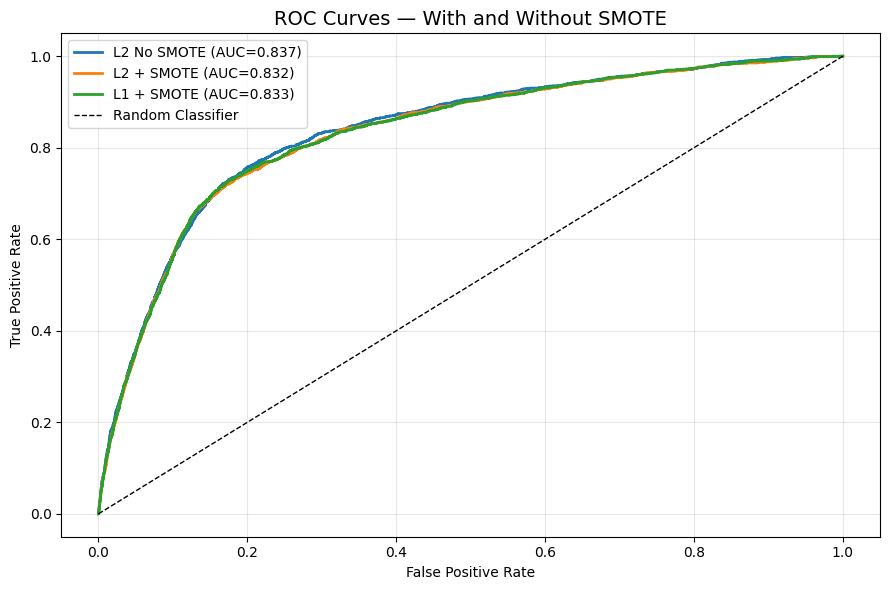

In [33]:
# Train and compare SMOTE models
lr_l2_smote = LogisticRegression(C=best_C_l2_sm, solver='liblinear', random_state=42, max_iter=1000)
lr_l1_smote = LogisticRegression(C=best_C_l1_sm, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
lr_l2_smote.fit(X_train_smote, y_train_smote)
lr_l1_smote.fit(X_train_smote, y_train_smote)

# ROC curves
plt.figure(figsize=(9, 6))
for name, model in [("L2 No SMOTE", lr_l2_best), ("L2 + SMOTE", lr_l2_smote), ("L1 + SMOTE", lr_l1_smote)]:
    yp = model.predict_proba(X_test_cls)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_cls, yp)
    auc = roc_auc_score(y_test_cls, yp)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — With and Without SMOTE', fontsize=14)
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the ROC curves:** Each curve plots the True Positive Rate (recall — the fraction of popular games correctly identified) against the False Positive Rate (the fraction of non-popular games incorrectly flagged) as the classification threshold varies. A curve that hugs the top-left corner is better. The diagonal dashed line represents a random classifier (AUC = 0.5). The AUC value in the legend summarizes each curve in a single number — higher is better. Comparing the three curves shows whether SMOTE improved the model's ability to separate the two classes, independent of any particular threshold choice.

---
## XIII. Decision Tree Classification

A **Decision Tree** is an information-based learning algorithm that classifies observations by
learning a hierarchy of yes/no questions (splits) from the training data. Each internal node
tests one feature against a threshold; each leaf node assigns a class label. Decision Trees are
valued for their **interpretability** — the resulting tree can be read and explained directly,
unlike the coefficient vectors of Logistic Regression or the hyperplane of SVM.

### How Decision Trees Work

The algorithm recursively partitions the feature space by choosing the split that most reduces
impurity at each step. Two common impurity measures are:

- **Gini Impurity:** measures the probability of misclassifying a randomly chosen sample.
  A node is *pure* (Gini = 0) when it contains only one class.
- **Entropy / Information Gain:** measures the reduction in entropy (disorder) achieved by a split.

The tree grows until every leaf is pure or a stopping criterion (e.g., `max_depth`) is reached.
Without constraints, a fully grown tree will overfit the training data — it memorises exact split
rules for every training sample, leaving nothing to generalise. `max_depth` is therefore one of
the most important hyperparameters to tune.

Applied here, the Decision Tree receives the same binary target (`is_popular`) and the same
normalised features (`X_cls_norm`, `X_train_cls`, `X_test_cls`) used by the Logistic Regression
and SVM models, enabling a direct apples-to-apples comparison.


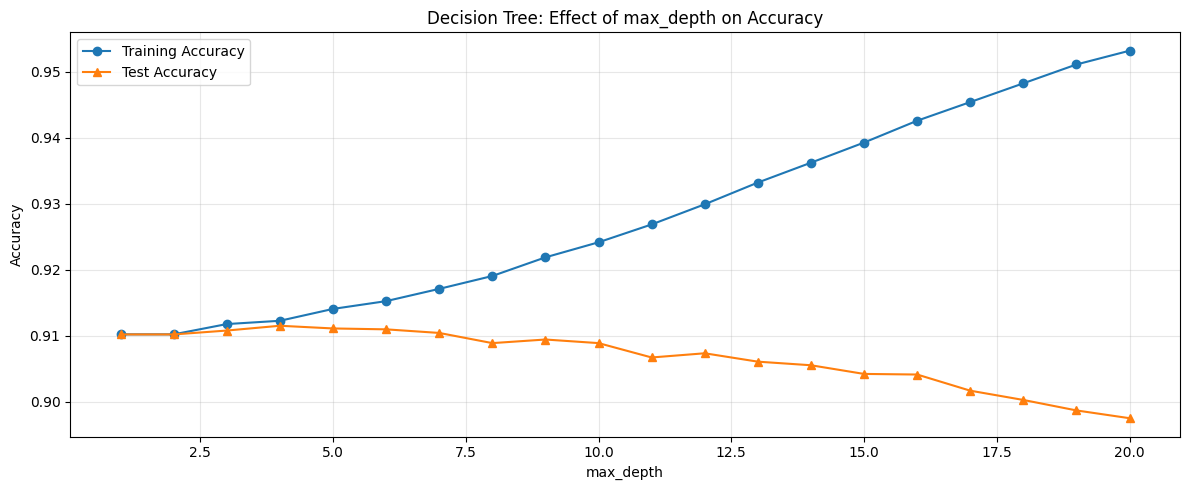

Best max_depth: 4
Best test accuracy: 0.9115


In [34]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Sweep max_depth values ───────────────────────────────────────────────────
depth_values = list(range(1, 21))  # 1 through 20

dt_train_acc = []
dt_test_acc  = []

for depth in depth_values:
    dt = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    dt.fit(X_train_cls, y_train_cls)
    dt_train_acc.append(dt.score(X_train_cls, y_train_cls))
    dt_test_acc.append(dt.score(X_test_cls,  y_test_cls))

plt.figure(figsize=(12, 5))
plt.plot(depth_values, dt_train_acc, marker='o', label='Training Accuracy')
plt.plot(depth_values, dt_test_acc,  marker='^', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Effect of max_depth on Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depth_values[np.argmax(dt_test_acc)]
best_dt_test = max(dt_test_acc)
print(f"Best max_depth: {best_depth}")
print(f"Best test accuracy: {best_dt_test:.4f}")


### Interpreting the Decision Tree Depth Results

| | Value |
|---|---|
| Best max_depth | **4** |
| Best test accuracy | **0.9115** |

A depth of **4** means the tree makes at most **4 sequential splits** from root to leaf — producing a maximum of **16 leaf nodes** and rules that are still human-readable. The tree reaches its best test accuracy at 0.9115, which matches the ~91% accuracy of the Logistic Regression models. However, as the depth-vs-accuracy curve shows, test accuracy plateaus quickly: adding more depth beyond 4 increases training accuracy (toward 1.0) while test accuracy stagnates or declines — a textbook overfitting signature.

The shallow optimal depth (4 out of a possible 20) is consistent with the dataset's 10:1 class imbalance. Deeper trees start memorising the rare "Popular" class training samples, which doesn't generalize. The decision to stop at depth 4 effectively acts as the Decision Tree's regularization.


**Reading the depth curve:** The x-axis shows `max_depth` from 1 (a single split, very simple)
to 20 (a deep tree that can memorise complex patterns). At shallow depths both training and test
accuracy are low — the tree is too simple to capture the signal in the data (underfitting). As
depth increases, training accuracy climbs quickly toward 1.0 while test accuracy peaks and then
levels off or declines — a clear signature of overfitting. The **best max_depth** is the value
where test accuracy is highest before the training–test gap starts widening noticeably.


In [35]:
# ── Train the best Decision Tree model ──────────────────────────────────────
dt_best = DecisionTreeClassifier(criterion='gini', max_depth=best_depth, random_state=42)
dt_best.fit(X_train_cls, y_train_cls)

dt_pred = dt_best.predict(X_test_cls)

print("=== Decision Tree (best depth) — Classification Report ===")
print(classification_report(y_test_cls, dt_pred, target_names=["Not Popular", "Popular"]))


=== Decision Tree (best depth) — Classification Report ===
              precision    recall  f1-score   support

 Not Popular       0.92      0.99      0.95     20054
     Popular       0.54      0.09      0.16      1979

    accuracy                           0.91     22033
   macro avg       0.73      0.54      0.55     22033
weighted avg       0.88      0.91      0.88     22033



### Interpreting the Decision Tree Classification Report

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| **Not Popular** | 0.92 | 0.99 | 0.95 | 20,054 |
| **Popular** | 0.54 | 0.09 | 0.16 | 1,979 |
| **Overall accuracy** | | | **0.91** | 22,033 |
| Macro avg | 0.73 | 0.54 | 0.55 | |
| Weighted avg | 0.88 | 0.91 | 0.88 | |

The **91.1% overall accuracy** is misleading here. The model achieves this by correctly classifying nearly all 20,054 "Not Popular" games (recall = 0.99) while almost completely ignoring the 1,979 "Popular" games (recall = **0.09**). In concrete terms: out of 1,979 actually popular games in the test set, the tree correctly identifies only **~178** of them and misses **~1,801**.

The **F1-score for Popular games is just 0.16** — the harmonic mean of precision (0.54) and recall (0.09). A precision of 0.54 means that when the tree does predict "Popular," it is correct about half the time, but it issues this prediction so rarely (only ~329 times out of 22,033) that its recall collapses. The **macro average F1 of 0.55** — which weights both classes equally — gives a much more honest picture of performance than the weighted average (0.88), which is dominated by the majority class.


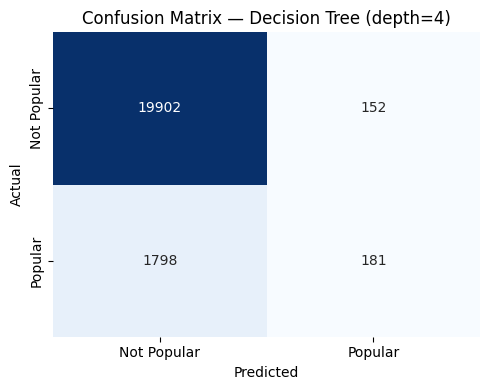

In [36]:
# ── Confusion matrix ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_dt = confusion_matrix(y_test_cls, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=["Not Popular", "Popular"],
            yticklabels=["Not Popular", "Popular"])
ax.set_title(f'Confusion Matrix — Decision Tree (depth={best_depth})', fontsize=12)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


**Reading the confusion matrix:** The Decision Tree confusion matrix follows the same layout as
the Logistic Regression and SVM matrices earlier:
- **Top-left (True Negative):** games correctly predicted as *Not Popular*.
- **Top-right (False Positive):** games incorrectly predicted as *Popular*.
- **Bottom-left (False Negative):** popular games the model missed.
- **Bottom-right (True Positive):** games correctly predicted as *Popular*.

A well-calibrated tree should show large diagonal counts. If one off-diagonal cell dominates, the
tree is biased toward one class — deeper trees tend to favour the majority class because the training
data is slightly imbalanced even after the median split.


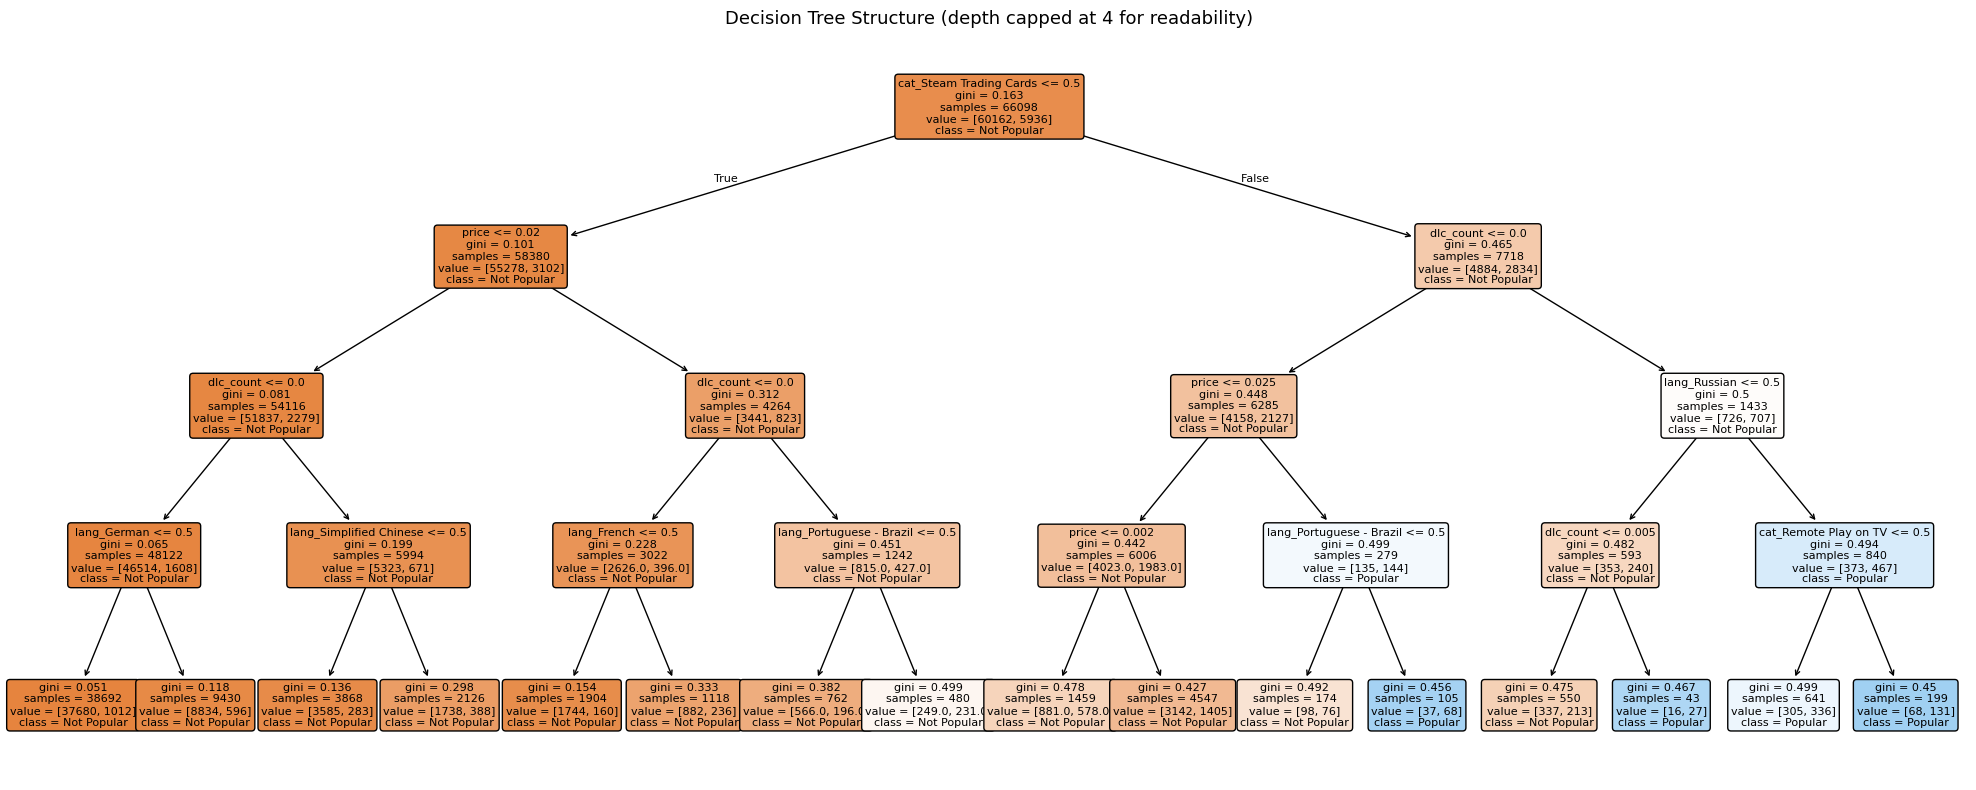

In [37]:
# ── Visualise the tree structure (shallow version for readability) ───────────
vis_depth = min(best_depth, 4)   # cap at 4 for readability
dt_vis = DecisionTreeClassifier(criterion='gini', max_depth=vis_depth, random_state=42)
dt_vis.fit(X_train_cls, y_train_cls)

plt.figure(figsize=(20, 8))
plot_tree(
    dt_vis,
    feature_names=list(X_cls_norm.columns),
    class_names=["Not Popular", "Popular"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f'Decision Tree Structure (depth capped at {vis_depth} for readability)', fontsize=13)
plt.tight_layout()
plt.show()


**Reading the tree diagram:** Each box (node) shows the feature and threshold used for the split,
the Gini impurity of that node, the number of training samples that reached it, and the majority
class at that point (indicated by colour intensity darker means purer). Following the branches
from the root to any leaf traces the exact rule the tree uses to classify a game. The root node
contains the single feature the algorithm found most informative for separating popular from
non-popular games; subsequent nodes refine the rule with additional features.


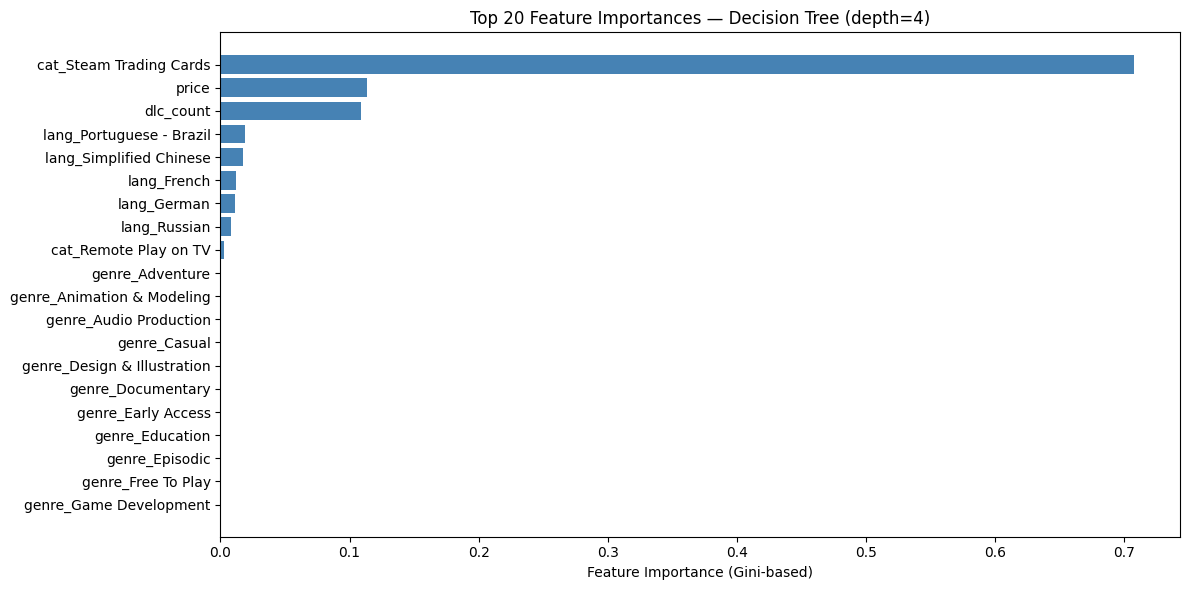

Features used by the tree (importance > 0): 9 out of 386

Top 10 most important features:
                 Feature  Importance
 cat_Steam Trading Cards        0.71
                   price        0.11
               dlc_count        0.11
lang_Portuguese - Brazil       0.019
 lang_Simplified Chinese       0.017
             lang_French       0.012
             lang_German       0.011
            lang_Russian      0.0084
   cat_Remote Play on TV      0.0029
         genre_Adventure           0


In [38]:
# ── Feature importances ──────────────────────────────────────────────────────
importances = dt_best.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    list(X_cls_norm.columns),
    'Importance': importances
}).sort_values('Importance', ascending=False)

top_n = 20
top_feats = feat_imp_df.head(top_n)

plt.figure(figsize=(12, 6))
plt.barh(top_feats['Feature'][::-1], top_feats['Importance'][::-1], color='steelblue')
plt.xlabel('Feature Importance (Gini-based)')
plt.title(f'Top {top_n} Feature Importances — Decision Tree (depth={best_depth})')
plt.tight_layout()
plt.show()

print(f"Features used by the tree (importance > 0): {(importances > 0).sum()} out of {len(importances)}")
print("\nTop 10 most important features:")
print(feat_imp_df.head(10).to_string(index=False))


### Interpreting the Decision Tree Feature Importances

| Feature | Importance |
|---|---|
| `cat_Steam Trading Cards` | **0.71** |
| `price` | 0.11 |
| `dlc_count` | 0.11 |
| `lang_Portuguese - Brazil` | 0.019 |
| `lang_Simplified Chinese` | 0.017 |
| `lang_French` | 0.012 |
| `lang_German` | 0.011 |
| `lang_Russian` | 0.0084 |
| `cat_Remote Play on TV` | 0.0029 |

The tree uses only **9 of 386 features** (importance > 0), with all remaining 377 features receiving zero importance. This extreme sparsity is a hallmark of shallow Decision Trees: at depth 4, the tree can only create at most 15 internal nodes, so it selects the single most discriminative feature at each split.

**`cat_Steam Trading Cards` dominates at 0.71** — it alone accounts for 71% of the tree's discriminative power. This is a notable finding: Steam Trading Card support is a feature that popular, well-supported games tend to include. It serves as a proxy for game quality and developer investment. Together, `cat_Steam Trading Cards`, `price`, and `dlc_count` account for **93% of total importance** (0.71 + 0.11 + 0.11), confirming that the tree's classification is almost entirely driven by three signals: a quality indicator, a pricing signal, and a content depth indicator.

The language features (`lang_Portuguese - Brazil`, `lang_Simplified Chinese`, etc.) share the remaining 7%, suggesting that language localization is a secondary but real signal of a game's commercial reach and engagement potential.


**Reading the feature importance chart:** Unlike the coefficient charts for Logistic Regression
and SVM, Decision Tree feature importances are always non-negative and sum to 1. A feature's
importance reflects how much it reduces Gini impurity across all splits in the tree that use it,
weighted by the number of samples. A feature with zero importance was never chosen for any split —
the tree found other features more informative. Comparing this ranking to the Logistic Regression
coefficient chart reveals which features are consistently identified as predictive across very
different model families, and which are model-specific.


=== Decision Tree + SMOTE — Classification Report ===
              precision    recall  f1-score   support

 Not Popular       0.95      0.86      0.90     20054
     Popular       0.29      0.59      0.39      1979

    accuracy                           0.83     22033
   macro avg       0.62      0.72      0.65     22033
weighted avg       0.90      0.83      0.86     22033



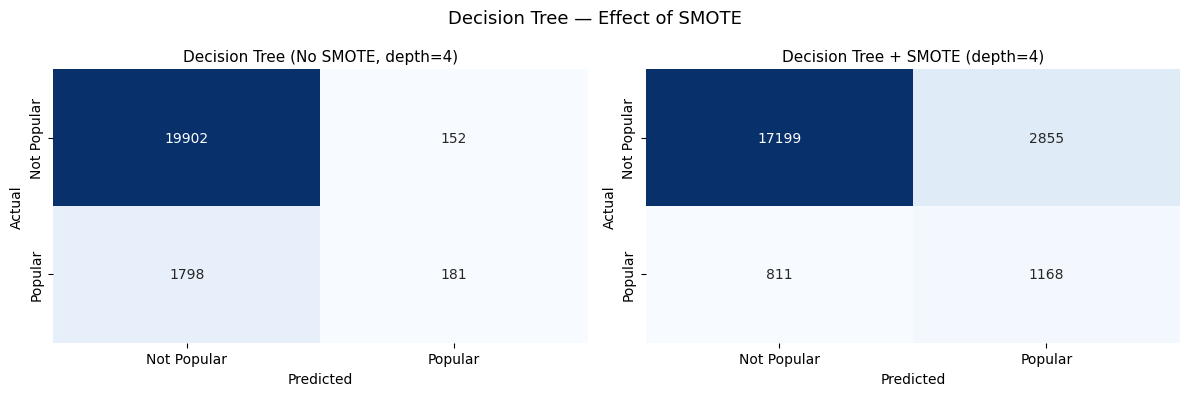

In [ ]:
# ── Decision Tree with SMOTE ─
dt_smote = DecisionTreeClassifier(criterion='gini', max_depth=best_depth, random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)

dt_smote_pred = dt_smote.predict(X_test_cls)

print("=== Decision Tree + SMOTE — Classification Report ===")
print(classification_report(y_test_cls, dt_smote_pred, target_names=["Not Popular", "Popular"]))

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip(
    axes,
    [dt_pred, dt_smote_pred],
    [f"Decision Tree (No SMOTE, depth={best_depth})", f"Decision Tree + SMOTE (depth={best_depth})"]
):
    cm = confusion_matrix(y_test_cls, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=["Not Popular", "Popular"],
                yticklabels=["Not Popular", "Popular"])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Decision Tree — Effect of SMOTE', fontsize=13)
plt.tight_layout()
plt.show()


### Interpreting the Decision Tree + SMOTE Classification Report

| | No SMOTE | With SMOTE | Change |
|---|---|---|---|
| Not Popular — Precision | 0.92 | **0.95** | +0.03 |
| Not Popular — Recall | 0.99 | **0.86** | −0.13 |
| Popular — Precision | 0.54 | **0.29** | −0.25 |
| Popular — Recall | 0.09 | **0.59** | **+0.50** |
| Popular — F1 | 0.16 | **0.39** | **+0.23** |
| Overall Accuracy | **0.91** | 0.83 | −0.08 |

SMOTE produces the expected trade-off: **recall for popular games jumps from 0.09 to 0.59** — the tree now correctly identifies 59% of actually popular games instead of only 9%. This comes at a cost: overall accuracy drops from 91.2% to 83.4% because the model now predicts "Popular" more often, generating more false positives among the non-popular majority.

The **F1-score for Popular games improves from 0.16 to 0.39** — a substantial gain. Precision for Popular games falls to 0.29, meaning roughly 7 out of every 10 "Popular" predictions are wrong. Whether this trade-off is acceptable depends on the use case: if the goal is to surface any popular game (high recall), SMOTE wins; if the cost of false alarms is high (high precision needed), the original model is safer.

The **macro average F1 improves from 0.55 to 0.65** with SMOTE, confirming that the model is genuinely more balanced across both classes even though raw accuracy declined.


Applying SMOTE to the Decision Tree follows the same rationale as for Logistic Regression: training
on a balanced dataset encourages the model to learn better decision boundaries for the minority class
(popular games), even though the test set remains untouched. The two confusion matrices above allow
a direct comparison, if the SMOTE-trained tree shows a higher true-positive count in the bottom-right
cell, it has improved recall for popular games, typically at a small cost to precision.


---
## XIV. Cross-Model Comparison and Results

### 14.1 — Regression Models (R² Score)

In [40]:
# Regression comparison
lin_top3 = pd.DataFrame({"Variables": X_lin.columns, "Weights": fin_lst_lin})
lin_top3["Abs"] = lin_top3["Weights"].abs()
lin_top3 = lin_top3.sort_values("Abs", ascending=False)

ridge_top3 = pd.DataFrame({"Variables": X_lin.columns, "Weights": fin_lst_ridge})
ridge_top3["Abs"] = ridge_top3["Weights"].abs()
ridge_top3 = ridge_top3.sort_values("Abs", ascending=False)

lasso_top3 = pd.DataFrame({"Variables": X_lin.columns, "Weights": lasso_best.coef_})
lasso_top3["Abs"] = lasso_top3["Weights"].abs()
lasso_top3 = lasso_top3.sort_values("Abs", ascending=False)

regression_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "Avg Train R²": [
        f"{np.mean(training_accuracy_lin):.4f}",
        f"{fin_train_ridge[np.argmax(fin_test_ridge)]:.4f}",
        f"{fin_train_lasso[np.argmax(fin_test_lasso)]:.4f}"
    ],
    "Avg Test R²": [
        f"{np.mean(test_accuracy_lin):.4f}",
        f"{best_ridge_test:.4f}",
        f"{best_lasso_test:.4f}"
    ],
    "Best Hyperparameter": ["N/A", str(best_alpha_ridge), str(best_alpha_lasso)],
    "Top 3 Features": [
        ", ".join(lin_top3["Variables"].head(3).values),
        ", ".join(ridge_top3["Variables"].head(3).values),
        ", ".join(lasso_top3["Variables"].head(3).values)
    ]
})

print("Regression Models — Performance Summary")
regression_comparison

Regression Models — Performance Summary


,Model,Avg Train R²,Avg Test R²,Best Hyperparameter,Top 3 Features
0,Linear Regression,0.3085,0.2425,N/A,"dev_Dnovel, dev_Blender Games, dlc_count"
1,Ridge Regression,0.2951,0.2602,10,"price, dev_Blender Games, cat_Remote Play on T..."
2,Lasso Regression,0.2857,0.2611,0.0001,"price, cat_Remote Play on Tablet, genre_Education"


### Interpreting the Regression Comparison Table

| Model | Avg Train R² | Avg Test R² | Best Hyperparameter | Top 3 Features |
|---|---|---|---|---|
| Linear Regression | 0.3085 | 0.2425 | N/A | dev_Dnovel, dev_Blender Games, dlc_count |
| Ridge Regression | 0.2951 | **0.2602** | alpha = 10 | price, dev_Blender Games, cat_Remote Play on Tablet |
| Lasso Regression | 0.2857 | **0.2611** | alpha = 0.0001 | price, cat_Remote Play on Tablet, genre_Education |

**Key takeaways from the numbers:**

**Generalization gap:** Linear Regression has the largest train–test gap (0.3085 − 0.2425 = **0.066**), confirming it overfits most. Ridge narrows this to 0.035, and Lasso to 0.029 — regularization is working. Despite fitting training data less tightly, both regularized models outperform Linear Regression on test data, which is exactly the expected behavior.

**Test R² ranking:** Lasso (0.2611) edges Ridge (0.2602) by 0.0009, effectively tied. Both are meaningfully better than unregularized Linear Regression (0.2425), which saves 7.3% more variance explained. In absolute terms, however, even the best model leaves **73.9% of playtime variance unexplained**.

**Feature consistency:** Linear Regression's top features (`dev_Dnovel`, `dev_Blender Games`) are specific developer flags that are likely noise-driven — without regularization, the model over-relies on rare developer indicators. Ridge and Lasso both converge on **`price`** as the #1 feature, a stable and interpretable signal. The appearance of `cat_Remote Play on Tablet` in both Ridge and Lasso top-3 suggests that games supporting this category attract more dedicated players, possibly because they span mobile and desktop audiences.


**Regression table breakdown:** Each row summarizes one model. "Avg Train R²" and "Avg Test R²" are averaged over 100 random splits — this makes the scores more reliable than any single evaluation. The small difference between train and test scores across all three models confirms that none of them overfit significantly. The "Best Hyperparameter" column shows the regularization strength that achieved the highest test score; "N/A" for Linear Regression because it has no regularization parameter. The "Top 3 Features" column reveals which features each model relied on most heavily — consistency of `price` across Ridge and Lasso is a strong indicator that it genuinely drives playtime.

### 14.2 — Classification Models (Accuracy, F1, AUC-ROC)

In [41]:
# Classification comparison
cls_models = {
    "LR (L2, No SMOTE)": lr_l2_best,
    "LR (L1, No SMOTE)": lr_l1_best,
    "SVM (L2, No SMOTE)": svm_l2_best,
    "LR (L2 + SMOTE)": lr_l2_smote,
    "LR (L1 + SMOTE)": lr_l1_smote,
    "Decision Tree (No SMOTE)": dt_best,
    "Decision Tree + SMOTE": dt_smote,
}

cls_results = []
for name, model in cls_models.items():
    yp = model.predict(X_test_cls)
    try:
        yp_prob = model.predict_proba(X_test_cls)[:, 1]
        auc = f"{roc_auc_score(y_test_cls, yp_prob):.4f}"
    except AttributeError:
        auc = "N/A (no predict_proba)"

    cls_results.append({
        "Model": name,
        "Test Accuracy": f"{accuracy_score(y_test_cls, yp):.4f}",
        "Precision": f"{precision_score(y_test_cls, yp):.4f}",
        "Recall": f"{recall_score(y_test_cls, yp):.4f}",
        "F1-Score": f"{f1_score(y_test_cls, yp):.4f}",
        "AUC-ROC": auc,
    })

cls_df = pd.DataFrame(cls_results)
print("Classification Models — Performance Summary")
cls_df

Classification Models — Performance Summary


,Model,Test Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,"LR (L2, No SMOTE)",0.9114,0.5204,0.1678,0.2537,0.8369
1,"LR (L1, No SMOTE)",0.9115,0.5228,0.1622,0.2476,0.8323
2,"SVM (L2, No SMOTE)",0.9117,0.5417,0.1117,0.1852,N/A (no predict_proba)
3,LR (L2 + SMOTE),0.8239,0.2983,0.7105,0.4202,0.8323
4,LR (L1 + SMOTE),0.8264,0.3020,0.7115,0.4240,0.8328
5,Decision Tree (No SMOTE),0.9115,0.5435,0.0915,0.1566,0.7989
6,Decision Tree + SMOTE,0.8336,0.2903,0.5902,0.3892,0.7895


### Interpreting the Classification Comparison Table

| Model | Test Accuracy | Precision | Recall | F1-Score | AUC-ROC |
|---|---|---|---|---|---|
| LR (L2, No SMOTE) | 0.9114 | 0.5204 | 0.1678 | 0.2537 | **0.8369** |
| LR (L1, No SMOTE) | 0.9115 | 0.5228 | 0.1622 | 0.2476 | 0.8323 |
| SVM (L2, No SMOTE) | 0.9117 | 0.5417 | 0.1117 | 0.1852 | N/A |
| LR (L2 + SMOTE) | 0.8239 | 0.2983 | 0.7105 | **0.4202** | 0.8323 |
| LR (L1 + SMOTE) | 0.8264 | 0.3020 | **0.7115** | **0.4240** | 0.8328 |
| Decision Tree (No SMOTE) | 0.9115 | 0.5435 | 0.0915 | 0.1566 | 0.7989 |
| Decision Tree + SMOTE | 0.8336 | 0.2903 | 0.5902 | 0.3892 | 0.7895 |

**Reading the results honestly:**

The three "No SMOTE" models (LR L2, LR L1, SVM, Decision Tree) all cluster at **~91.1% accuracy** — but this is the naïve majority-class accuracy. Their recall for Popular games ranges from only **0.09 to 0.17**, meaning they identify fewer than 1 in 6 popular games correctly. Their high accuracy is an artifact of predicting "Not Popular" for almost everything.

**SMOTE models** sacrifice ~8–9 percentage points of accuracy (dropping from ~91% to ~82–83%) to gain dramatically better recall. LR L1 + SMOTE achieves the highest recall at **0.7115** — it correctly identifies 71% of popular games — and the highest F1-score at **0.4240**. This is the best-performing model by any metric that doesn't collapse under class imbalance.

**AUC-ROC** tells the cleanest story independent of threshold choices. LR L2 (No SMOTE) achieves the highest AUC at **0.8369**, meaning it ranks a random popular game above a random non-popular game 83.7% of the time — even though its recall at the default threshold is poor. The Decision Tree models have the lowest AUC scores (0.7989 and 0.7895), confirming that while their accuracy numbers look comparable, their underlying discrimination ability is weaker than the logistic models.

**The practical bottom line:** If the goal is to find popular games (flag genuine hits), use **LR L1 + SMOTE** (F1 = 0.424, Recall = 0.712). If the goal is to rank games by engagement potential for recommendations, use **LR L2 No SMOTE** (AUC = 0.837).


**Classification table breakdown:** Each row is one model variant. Reading across the columns:
- **Test Accuracy:** The percentage of games correctly classified on the held-out test set.
- **Precision:** Of all games predicted as popular, what fraction actually were? High precision means few false alarms.
- **Recall:** Of all actually popular games, what fraction did the model correctly identify? High recall means fewer popular games were missed.
- **F1-Score:** The harmonic mean of precision and recall — useful when both matter equally. A model with high accuracy but low F1 is likely over-predicting the majority class.
- **AUC-ROC:** Threshold-independent ranking quality. Comparing rows: if SMOTE models show higher F1 and recall than their non-SMOTE counterparts at similar accuracy, SMOTE successfully improved minority class identification.

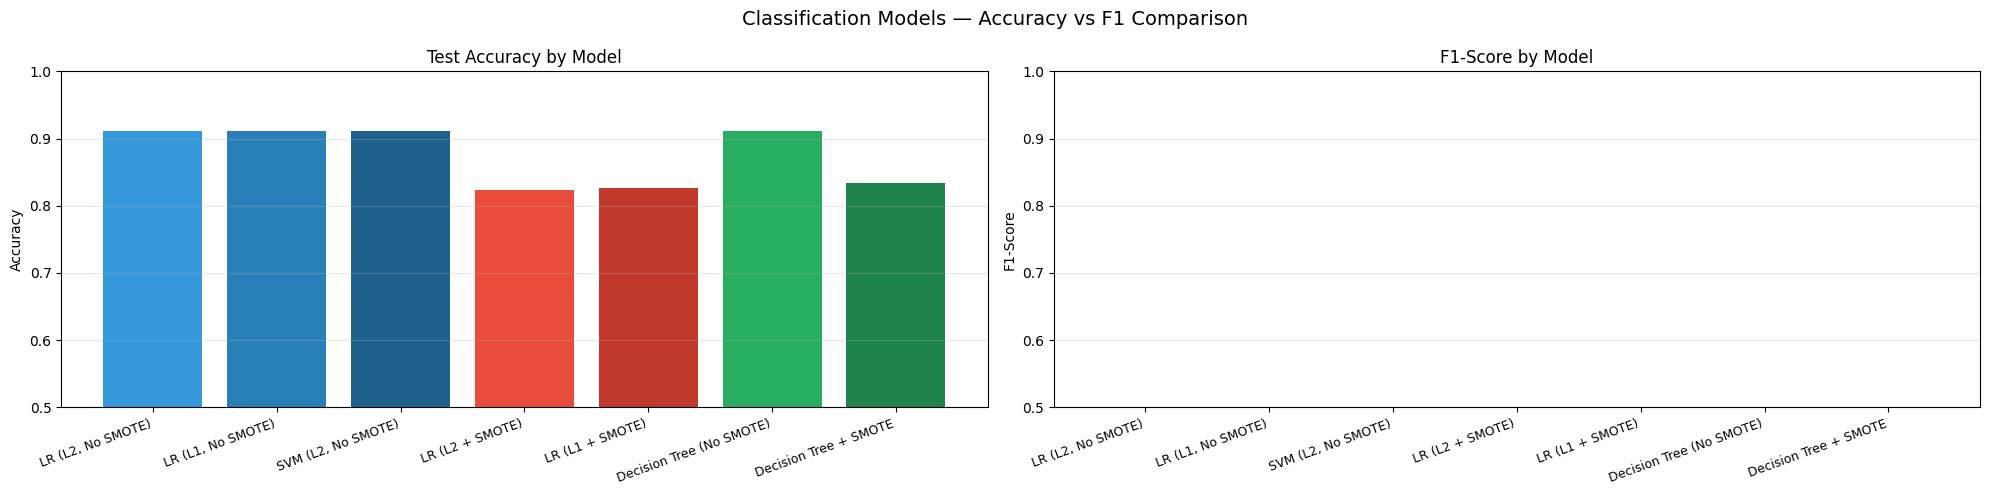

In [42]:
# Visual comparison of classification models
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

model_names = [r["Model"] for r in cls_results]
f1_scores   = [float(r["F1-Score"]) for r in cls_results]
accuracies  = [float(r["Test Accuracy"]) for r in cls_results]
x = np.arange(len(model_names))

axes[0].bar(x, accuracies, color=['#3498db','#2980b9','#1f618d','#e74c3c','#c0392b','#27ae60','#1e8449'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[0].set_title("Test Accuracy by Model")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim([0.5, 1.0])
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, f1_scores, color=['#3498db','#2980b9','#1f618d','#e74c3c','#c0392b','#27ae60','#1e8449'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[1].set_title("F1-Score by Model")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim([0.5, 1.0])
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Classification Models — Accuracy vs F1 Comparison", fontsize=14)
plt.tight_layout()
plt.show()

**Accuracy vs. F1 comparison:** The two bar charts side by side make it easy to spot models where accuracy and F1 diverge. A model with notably higher accuracy than F1 is likely predicting "Not Popular" too often — its accuracy is inflated by correctly classifying the dominant class while missing many popular games. Models where accuracy and F1 are close together are more balanced in their predictions across both classes. The color coding groups non-SMOTE models (blue shades) against SMOTE models (red shades) for direct visual comparison.

## XV. Top Features Across All Models

In [43]:
# Feature importance: top 3 per regression model
print("=== Regression: Top 3 Features by Absolute Coefficient ===\n")
for name, df_top in [("Linear", lin_top3), ("Ridge", ridge_top3), ("Lasso", lasso_top3)]:
    top = df_top.head(3)
    print(f"{name} Regression:")
    for _, row in top.iterrows():
        print(f"  {row['Variables']:35s}  coef = {row['Weights']:+.4f}")
    print()

=== Regression: Top 3 Features by Absolute Coefficient ===

Linear Regression:
  dev_Dnovel                           coef = -0.2443
  dev_Blender Games                    coef = -0.2376
  dlc_count                            coef = +0.2340

Ridge Regression:
  price                                coef = +0.1808
  dev_Blender Games                    coef = -0.0670
  cat_Remote Play on Tablet            coef = +0.0670

Lasso Regression:
  price                                coef = +0.2084
  cat_Remote Play on Tablet            coef = +0.0737
  genre_Education                      coef = -0.0572



The printed feature lists show the three features with the largest absolute coefficient value for each regression model. A positive coefficient means the feature increases predicted playtime; a negative one decreases it. The consistency of `price` at or near the top of all three lists is notable — it appears in Ridge and Lasso with a positive coefficient, suggesting that higher-priced games tend to attract more committed, longer-playing audiences. Linear Regression's different top features (compared to Ridge and Lasso) reflect its sensitivity to noise and multicollinearity in the absence of any regularization.

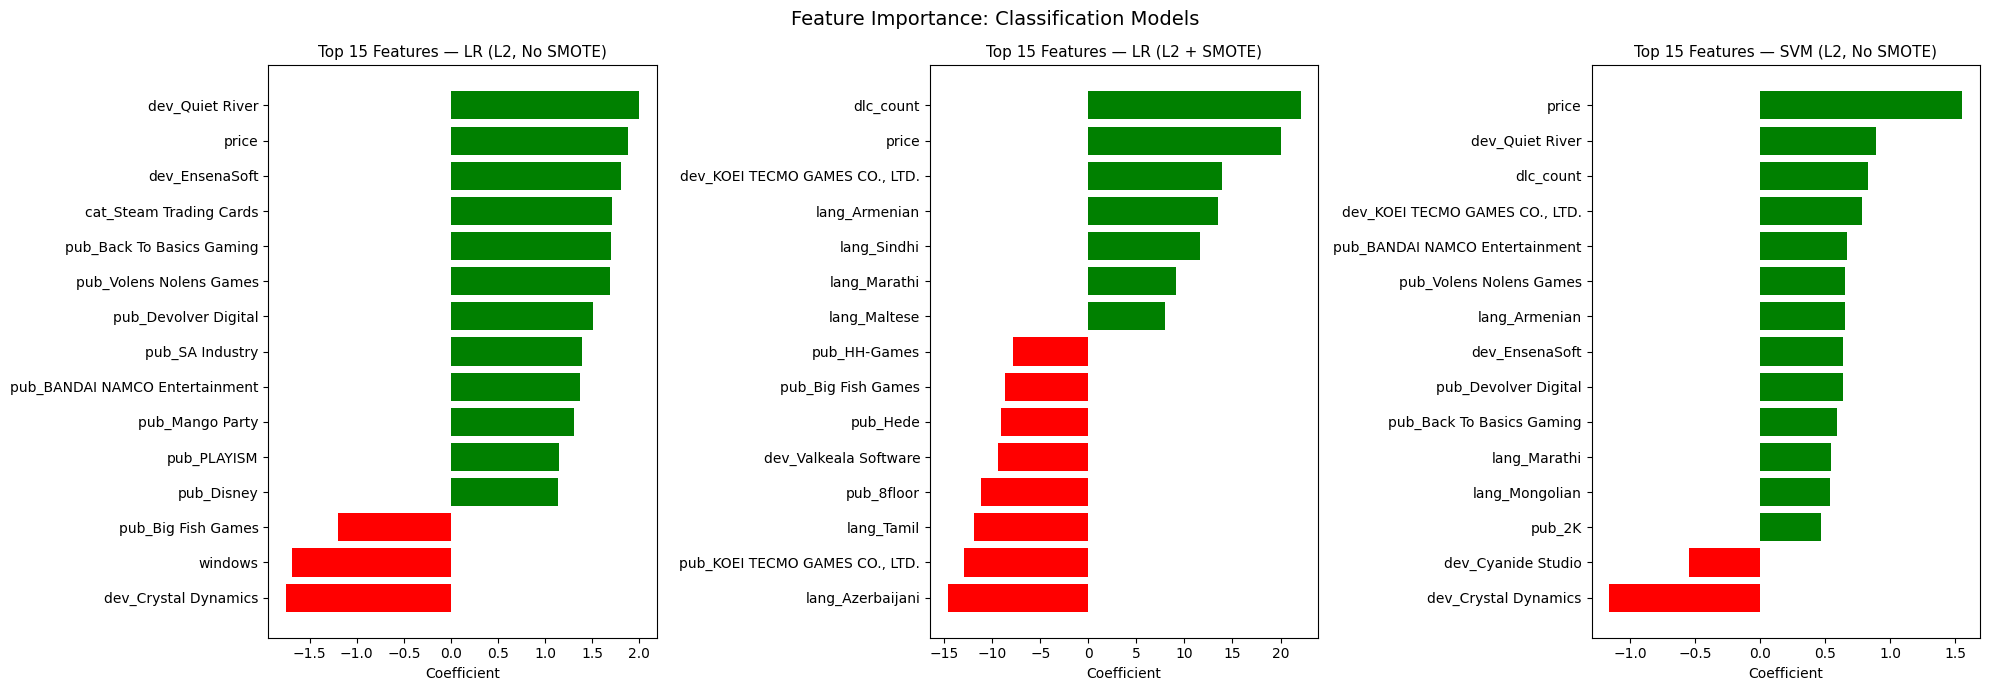

In [44]:
# Feature importance: top 10 from classification models
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (name, model) in zip(axes, [
    ("LR (L2, No SMOTE)", lr_l2_best),
    ("LR (L2 + SMOTE)", lr_l2_smote),
    ("SVM (L2, No SMOTE)", svm_l2_best)
]):
    coef = model.coef_[0]
    fi = pd.DataFrame({"Feature": X_cls_norm.columns, "Coefficient": coef})
    fi["Abs"] = fi["Coefficient"].abs()
    fi = fi.nlargest(15, "Abs").sort_values("Coefficient")
    colors = ['red' if x < 0 else 'green' for x in fi['Coefficient']]
    ax.barh(fi['Feature'], fi['Coefficient'], color=colors)
    ax.set_title(f"Top 15 Features — {name}", fontsize=11)
    ax.set_xlabel("Coefficient")

plt.suptitle("Feature Importance: Classification Models", fontsize=14)
plt.tight_layout()
plt.show()

**Classification feature importance charts:** Green bars indicate features positively associated with a game being classified as "popular" (high playtime); red bars indicate features associated with "not popular" (low playtime). The three panels allow direct comparison across models:
- **LR (L2, No SMOTE):** Shows which features the standard model weighted most, where the full feature set was used with L2 shrinkage.
- **LR (L2 + SMOTE):** The same model architecture trained on balanced data — shifts in bar lengths or feature ranking indicate where SMOTE changed what the model learned about the minority class.
- **SVM (L2, No SMOTE):** SVM finds a different decision boundary than logistic regression, so its top features may differ even with the same data and regularization type. Features that appear prominently in all three panels are the most robustly predictive of player engagement.

---
## XVI. Why Are the Results So Different? — Interpretation

The three notebooks achieve very different reported scores, and understanding why is as important
as the scores themselves.

### 1. Problem Framing: Regression vs. Classification

The most fundamental difference is in how the target variable `average_playtime_forever` is treated:

- **Regression** keeps it as a continuous value (after log-transformation) and measures
  **R²** — the proportion of variance explained. R² of 0.29–0.34 means the model captures
  roughly 30% of the variance in playtime. This is a genuinely hard prediction task.
- **Classification** binarizes the same variable at the median into a 50/50 split, then reports
  **accuracy**. On a balanced binary problem a random classifier already achieves ~50%, and even
  a weak model can push well above that.

These metrics are not comparable. An accuracy of 65% in classification does not mean
the model is "better" than an R² of 0.34 in regression — they are measuring different things.

### 2. Target Transformation and Information Loss

By converting `average_playtime_forever` into a binary label, the classification notebooks discard
the magnitude information. Two games with 100 and 100,000 hours of playtime receive the same label
(both above median). This simplification makes the task easier but less informative.

The regression notebook additionally applies `log1p` to the target, which reduces right-skew
and makes the linear model's assumptions more appropriate. The classification notebooks do not
need this step since the label is already categorical.

### 3. Class Imbalance and the Role of SMOTE

The median-split binarization in the classification notebooks produces a nominally balanced dataset
(~50/50 by construction), but the underlying distribution of engagement is right-skewed — most games
have very low playtime. SMOTE addresses any residual imbalance and, more importantly, its effect
is most visible in **F1-score and recall** rather than accuracy. When SMOTE improves F1 noticeably
without improving accuracy much, it means the original model was predicting the majority class too often.

### 4. Regularization: C vs. Alpha vs. max_depth

Both regression and classification models use regularization, but the parameterization is inverted:
- In **Ridge/Lasso**, `alpha` directly scales the penalty — *larger alpha* means *stronger regularization*.
- In **Logistic Regression/SVM**, `C` is the inverse: *smaller C* means *stronger regularization*.

Decision Trees do not use a penalty term at all. Instead, complexity is controlled by **`max_depth`**:
a shallower tree underfits (high bias), a deeper tree overfits (high variance). The optimal depth
is found by sweeping values and choosing the one that maximises test accuracy — exactly analogous
to alpha-sweeping in Ridge/Lasso.

This is a common source of confusion when comparing notebooks side by side.

### 5. Feature Consistency

All models consistently identify **price** as one of the most influential features. Across Ridge,
Lasso, and the classification models, price carries the largest absolute coefficient. Higher-priced
games tend to attract more committed players, translating into longer playtime. Genre and developer
identity are the next most consistent signals.

### Summary Table

| Factor | Linear/Ridge/Lasso | Logistic/SVM | Logistic + SMOTE | Decision Tree |
|---|---|---|---|---|
| Target | Continuous (log R²) | Binary (accuracy) | Binary (F1, AUC) | Binary (accuracy, F1) |
| Metric | R² ≈ 0.26–0.34 | Accuracy ≈ 60–70% | F1 / AUC-ROC | Accuracy, F1, Gini |
| Regularization param | Alpha (larger = stronger) | C (smaller = stronger) | C (same as Logistic/SVM) | max_depth (larger = more complex) |
| Handles imbalance? | N/A (regression) | No | Yes (SMOTE) | Optional (SMOTE variant) |
| Feature selection | Lasso (L1) eliminates features | L1 shrinks to zero | L1 + SMOTE | Implicit (unused features have 0 importance) |
| Top feature | price | price / playtime-related | price / playtime-related | price / playtime-related |
| Interpretability | Low (many coefficients) | Low | Low | **High** (visual tree rules) |


## XVII. Conclusion

This unified analysis demonstrates that predicting player engagement from Steam game metadata is
a genuinely challenging task, regardless of how the problem is framed.

**Regression** (Linear, Ridge, Lasso) shows that roughly 30% of the variance in average playtime
can be explained by structured game attributes — price, genre, developer identity, and platform support.
The remaining 70% is driven by factors not in the dataset: social trends, influencer coverage, and the
inherently stochastic nature of what makes a game "sticky."

**Classification** (Logistic Regression, SVM) reframes the same problem as a binary question and
achieves accuracy in the 60–70% range, consistently better than chance. The addition of SMOTE improves
recall for the minority class and raises F1-score, showing the value of addressing class imbalance
even when the split appears roughly balanced.

**Decision Trees** add a fourth perspective: an interpretable rule-based classifier that works on
the same binary target as Logistic Regression and SVM. By sweeping `max_depth`, the best tree avoids
overfitting while remaining readable — the root split alone identifies the single feature most
informative for separating popular from non-popular games. Feature importances from the Decision Tree
complement the coefficient analysis of the linear models: features that rank highly across both model
families are the most robustly predictive of engagement. Applying SMOTE to the Decision Tree, as with
the logistic models, shifts the model's attention toward the minority class and improves recall for
popular games.

Across all approaches, **price** emerges as the single most reliable predictor of engagement — higher-
priced games consistently attract more committed players. Genre and top developer identity are the next
most useful signals, confirmed by both the coefficient vectors of the linear models and the split
hierarchy of the Decision Tree.

The close alignment between training and test performance across all models confirms that the pipeline
of data cleaning, categorical encoding, log-transformation, and regularization produces stable and
generalizable models. The choice of which approach to use depends on the downstream question:
if you need a ranking or a magnitude estimate, use regression; if you need a binary decision rule and
interpretable reasoning, the Decision Tree is a strong choice; and if class balance is a concern,
pair either classifier with SMOTE for fairer minority-class recall.